## Causal Tracing (ROME)

Causal tracing was a methodology for locating where facts are stored in transformer LMs, introduced in the paper ["Locating and Editing Factual Associations in GPT" (Meng et al., 2023)](https://arxiv.org/abs/2202.05262). In this notebook, we will implement their method using this library and replicate the first causal tracing example in the paper (full figure 1 on page 2).

In [1]:
!pip install nnsight

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 4.4 MB/s eta 0:00:00


In [2]:
try:
    # This library is our indicator that the required installs
    # need to be done.
    import pyvene

except ModuleNotFoundError:
    !pip install git+https://github.com/stanfordnlp/pyvene.git

  Cloning https://github.com/stanfordnlp/pyvene.git to /tmp/pip-req-build-v7pb5dq9
  Running command git clone --filter=blob:none --quiet https://github.com/stanfordnlp/pyvene.git /tmp/pip-req-build-v7pb5dq9
  Resolved https://github.com/stanfordnlp/pyvene.git to commit 0d3f1f85065f87f849fd2cba060c69ecf69b65be
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.0 MB/s eta 0:00:00
  Created w

In [3]:
import torch
import pandas as pd
import numpy as np
from pyvene import embed_to_distrib, top_vals, format_token
from pyvene import (
    IntervenableModel,
    VanillaIntervention, Intervention,
    RepresentationConfig,
    IntervenableConfig,
    ConstantSourceIntervention,
    LocalistRepresentationIntervention
)
from pyvene import create_gpt2

%config InlineBackend.figure_formats = ['svg']
from plotnine import (
    ggplot,
    geom_tile,
    aes,
    facet_wrap,
    theme,
    element_text,
    geom_bar,
    geom_hline,
    scale_y_log10,
    xlab, ylab, ylim,
    scale_y_discrete, scale_y_continuous, ggsave
)
from plotnine.scales import scale_y_reverse, scale_fill_cmap
from tqdm import tqdm

titles={
    "block_output": "single restored layer in GPT2-XL",
    "mlp_activation": "center of interval of 10 patched mlp layer",
    "attention_output": "center of interval of 10 patched attn layer"
}

colors={
    "block_output": "Purples",
    "mlp_activation": "Greens",
    "attention_output": "Reds"
}

In [11]:
import os

# Load GPT-2 model
hf_token = os.getenv("HF_TOKEN")
from huggingface_hub import login
login(token=hf_token)

In [12]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
configxl, tokenizerxl, gptxl = create_gpt2(name="gpt2-xl")
gptxl.to(device)

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

loaded model


GPT2Model(
  (wte): Embedding(50257, 1600)
  (wpe): Embedding(1024, 1600)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-47): 48 x GPT2Block(
      (ln_1): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2SdpaAttention(
        (c_attn): Conv1D(nf=4800, nx=1600)
        (c_proj): Conv1D(nf=1600, nx=1600)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=6400, nx=1600)
        (c_proj): Conv1D(nf=1600, nx=6400)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
)

In [13]:
configmedium, tokenizermedium, gptmedium = create_gpt2(name="gpt2-medium")
gptmedium.to(device)

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

loaded model


GPT2Model(
  (wte): Embedding(50257, 1024)
  (wpe): Embedding(1024, 1024)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-23): 24 x GPT2Block(
      (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2SdpaAttention(
        (c_attn): Conv1D(nf=3072, nx=1024)
        (c_proj): Conv1D(nf=1024, nx=1024)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=4096, nx=1024)
        (c_proj): Conv1D(nf=1024, nx=4096)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
)

In [14]:
def restore_corrupted_with_interval_config(
    layer, stream="mlp_activation", window=10, num_layers=48, index=[0,1], embed_dim=1600):
    start = max(0, layer - window // 2)
    end = min(num_layers, layer - (-window // 2))
    config = IntervenableConfig(
        representations=[
            RepresentationConfig(
                0,       # layer
                "block_input",  # intervention type
            ),
        ] + [
            RepresentationConfig(
                i,       # layer
                stream,  # intervention type
        ) for i in range(start, end)],
        intervention_types=\
            [NoiseIntervention]+[VanillaIntervention]*(end-start),
    )
    return config

In [15]:
def analyze_sentence(model, tokenizer, config, sentence, target_token, index, save_path="./results_gpt", streams=["block_output", "mlp_activation", "attention_output"]):
    # Tokenize input
    base_input = tokenizer(sentence, return_tensors="pt").to(device)
    target_token_id = tokenizer.encode(target_token)[0]

    for stream in streams:
        data = []
        for layer_i in tqdm(range(model.config.n_layer), desc=f"Analyzing {stream}"):
            for pos_i in range(len(tokenizer.tokenize(sentence))):
                config = restore_corrupted_with_interval_config(layer=layer_i, stream=stream, num_layers=model.config.n_layer)
                intervenable = IntervenableModel(config, model)
                _, counterfactual_outputs = intervenable(
                    base_input,
                    [None] + [base_input] * (len(config.representations) - 1),
                    {
                        "sources->base": (
                            [None] + [[[pos_i]]] * (len(config.representations) - 1),
                            [[index]] + [[[pos_i]]] * (len(config.representations) - 1),
                        )
                    },
                )
                distrib = embed_to_distrib(model, counterfactual_outputs.last_hidden_state, logits=False)
                prob = distrib[0][-1][target_token_id].detach().cpu().item()
                data.append({"layer": layer_i, "pos": pos_i, "prob": prob})

        df = pd.DataFrame(data)
        os.makedirs(save_path, exist_ok=True)
        df.to_csv(f"{save_path}/{stream}_{target_token.replace(' ', '')}.csv")

In [16]:
class NoiseIntervention(ConstantSourceIntervention, LocalistRepresentationIntervention):
    def __init__(self, embed_dim, **kwargs):
        super().__init__()
        self.interchange_dim = embed_dim
        rs = np.random.RandomState(1)
        prng = lambda *shape: rs.randn(*shape)
        self.noise = torch.from_numpy(
            prng(1, 4, embed_dim)).to(device)
        self.noise_level = 0.13462981581687927

    def forward(self, base, source=None, subspaces=None):
        base[..., : self.interchange_dim] += self.noise * self.noise_level
        return base

    def __str__(self):
        return f"NoiseIntervention(embed_dim={self.embed_dim})"

In [17]:
sentence = "The Space Needle is in downtown"
target = " Seattle"
subject = [0, 1, 2, 3]
print(sentence, ":")
print("GPT2-xl: ")
analyze_sentence(gptxl, tokenizerxl, configxl, sentence, target, subject, f"./{target[1:]}/results_gptxl")
print("GPT2-medium: ")
analyze_sentence(gptmedium, tokenizermedium, configmedium, sentence, target, subject, f"./{target[1:]}/results_medium")
print("")

The Space Needle is in downtown :
GPT2-xl: 


Analyzing attention_output: 100%|██████████| 48/48 [02:05<00:00,  2.62s/it]


GPT2-medium: 


Analyzing attention_output: 100%|██████████| 24/24 [00:30<00:00,  1.27s/it]

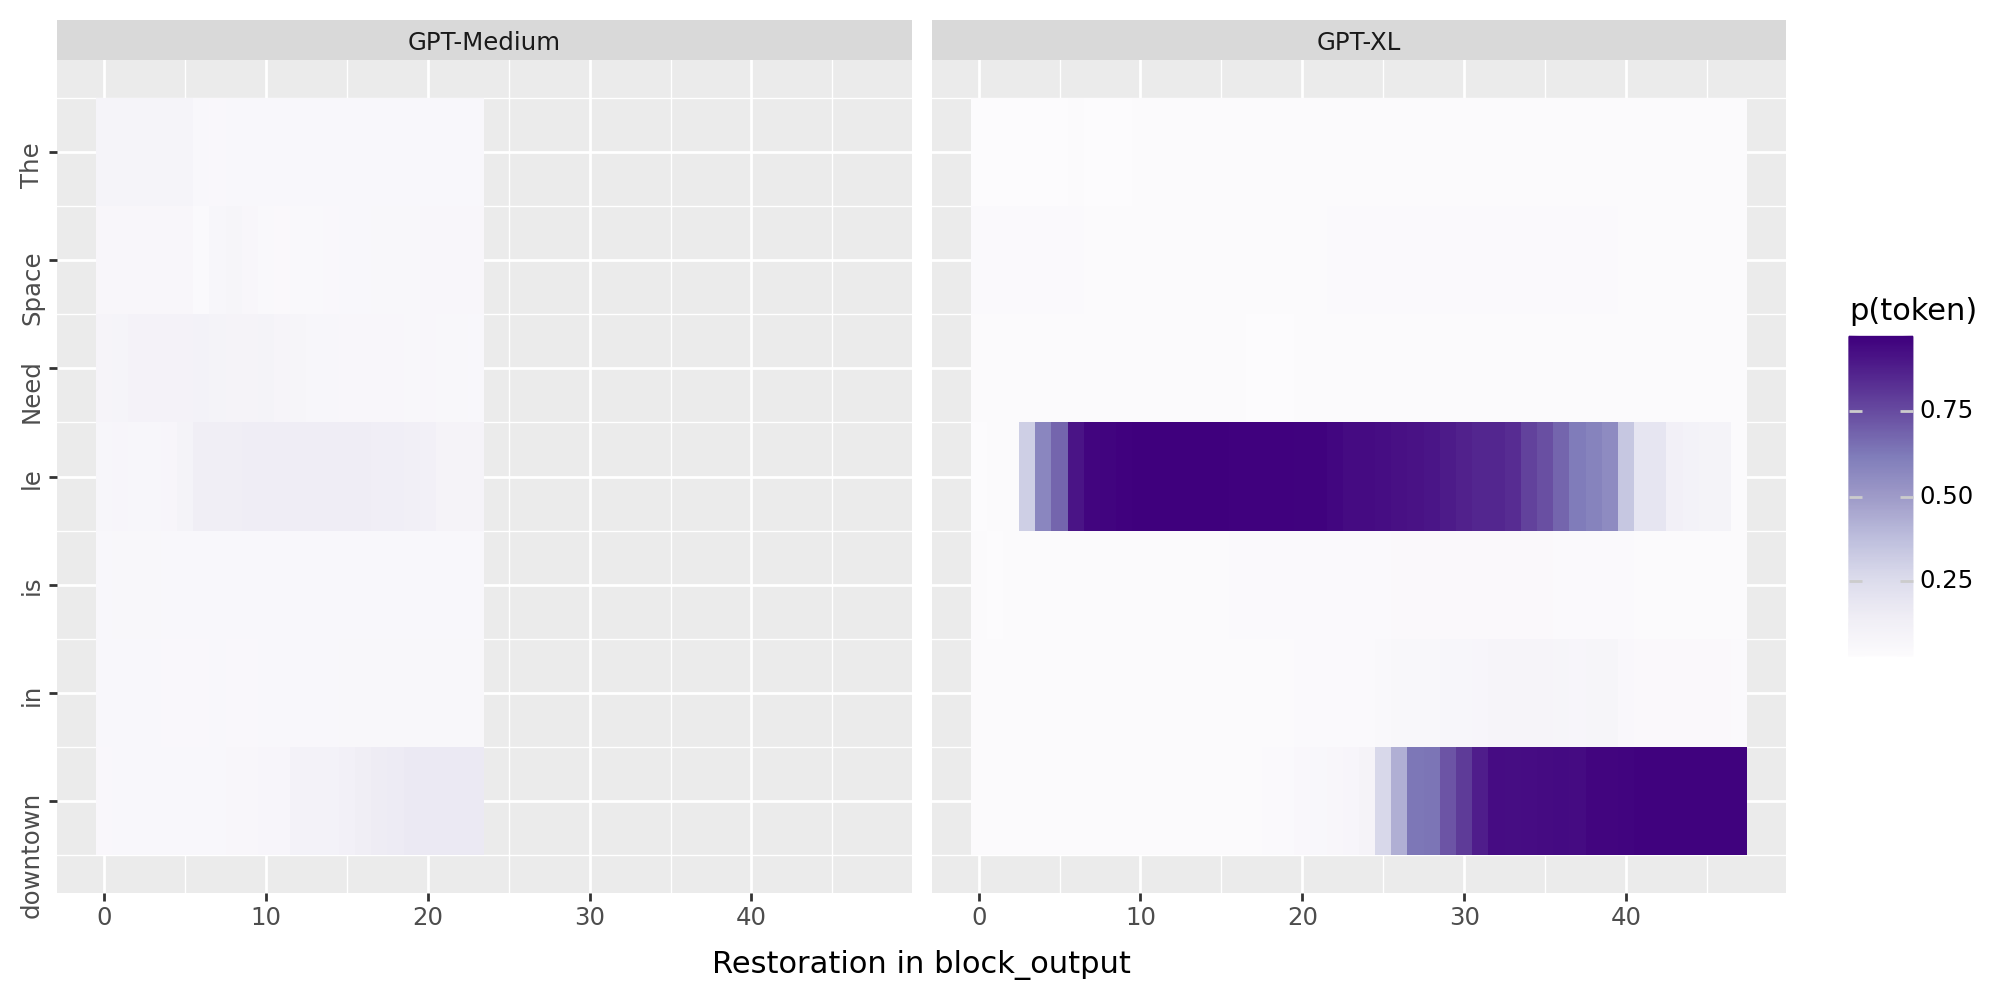

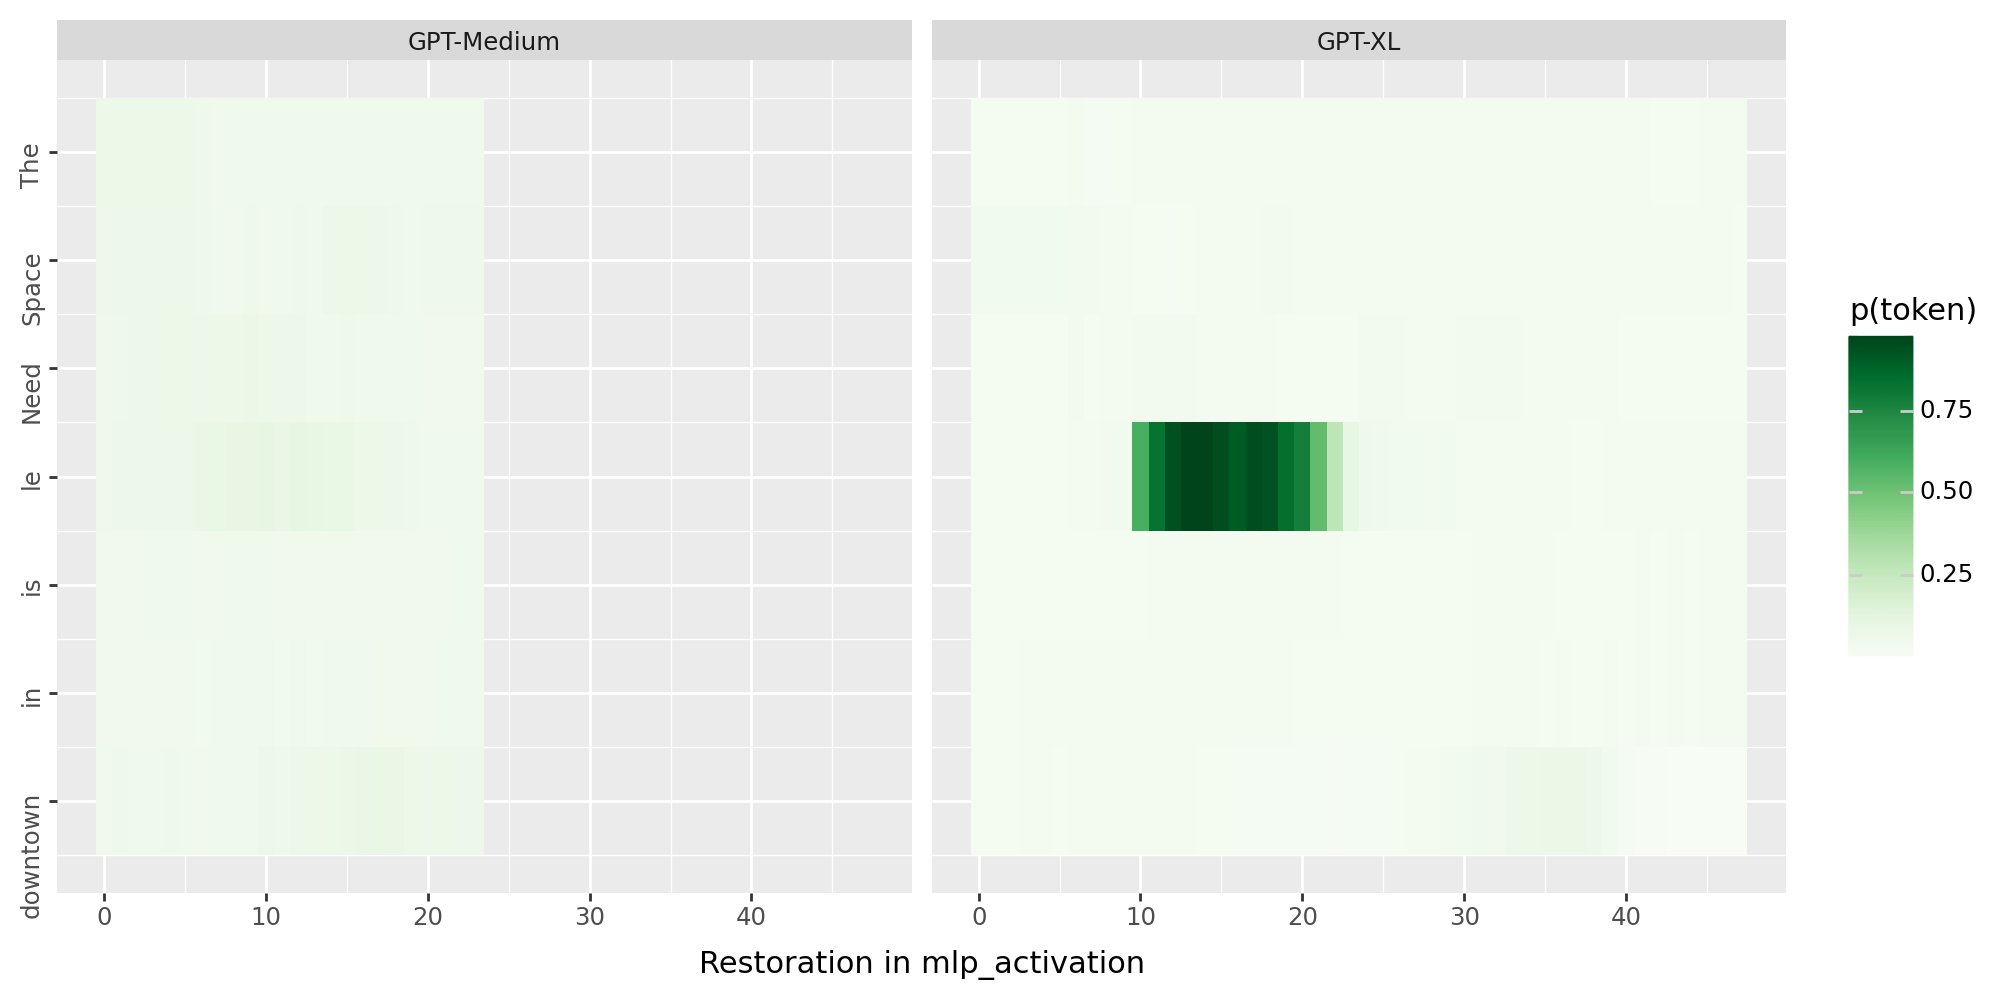

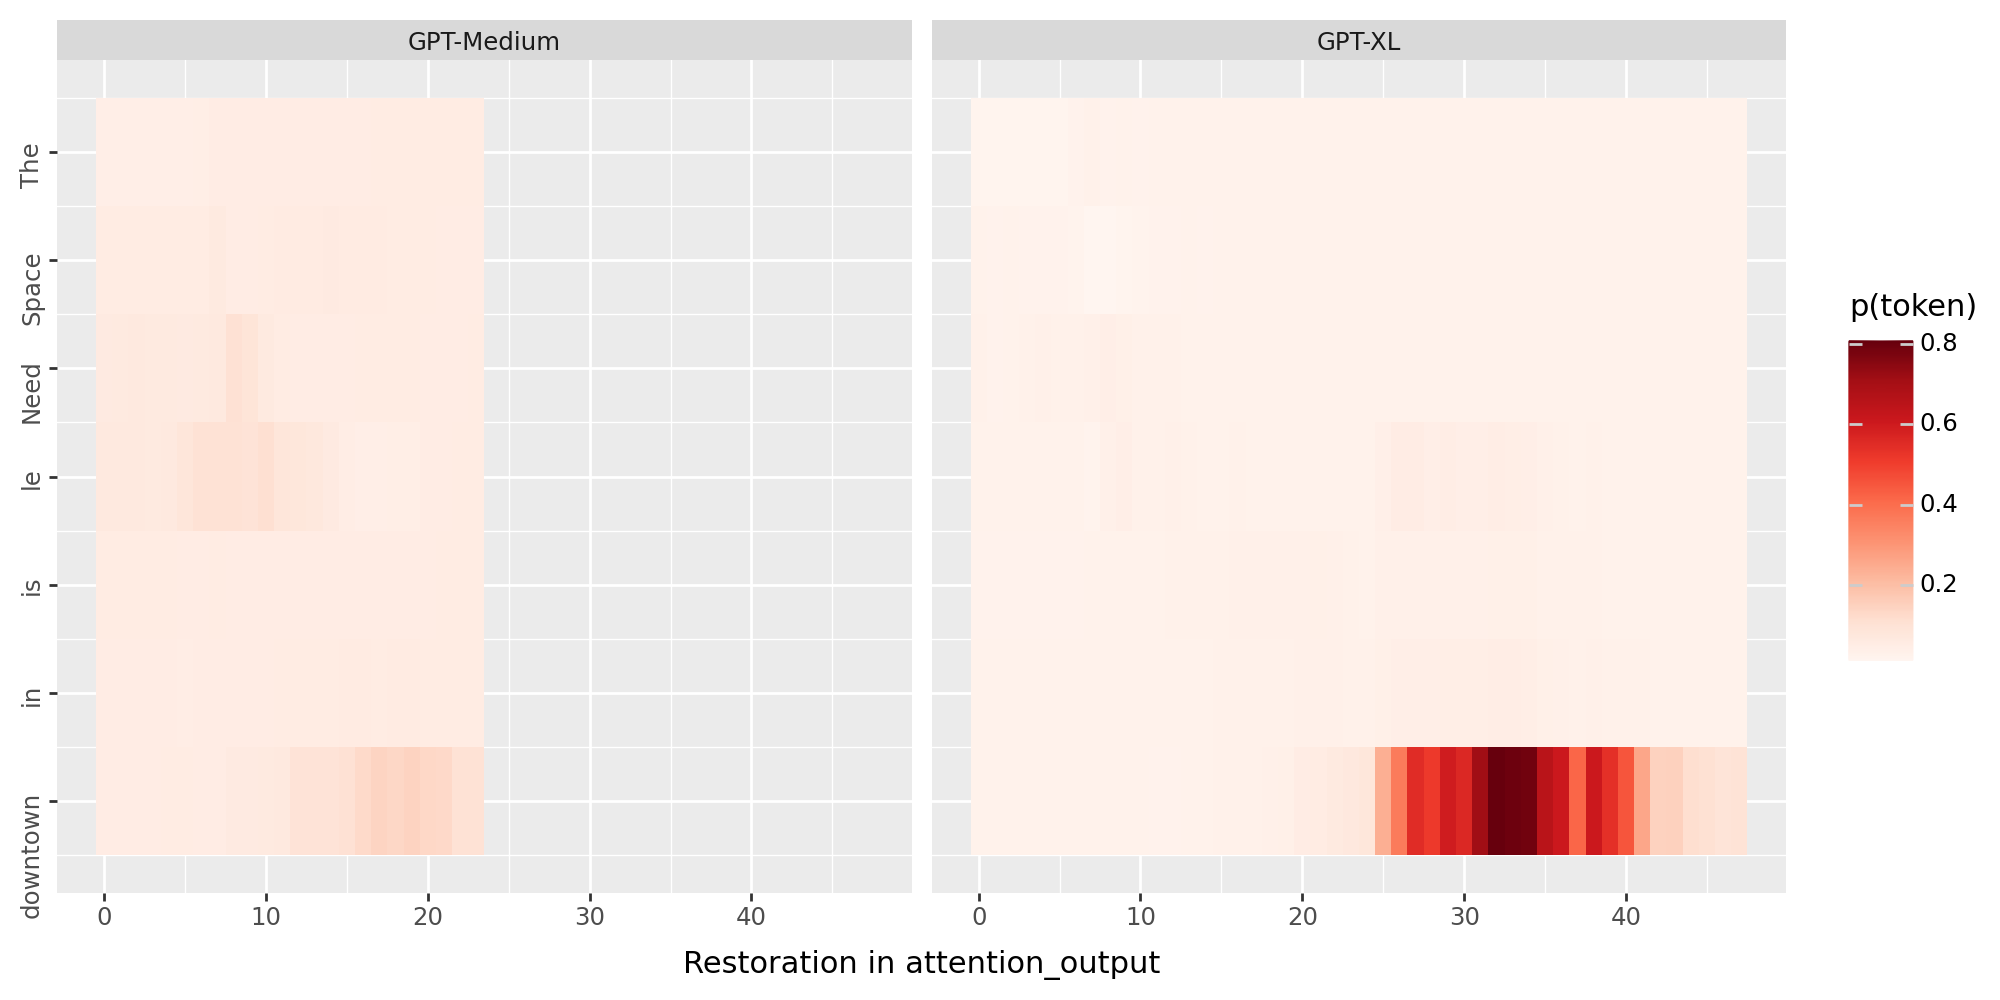

In [25]:
import pandas as pd
from plotnine import *

def plot_results_comparison(target, sentence, streams=["block_output", "mlp_activation", "attention_output"]):
    for stream in streams:
        # Generate file paths for both models
        file1 = f"./{target[1:]}/results_gptxl/{stream}_{target[1:]}.csv"
        file2 = f"./{target[1:]}/results_medium/{stream}_{target[1:]}.csv"

        # Load data from both files
        df1 = pd.read_csv(file1)
        df2 = pd.read_csv(file2)

        # Add a column to identify the model
        df1["model"] = "GPT-XL"
        df2["model"] = "GPT-Medium"

        # Concatenate the two DataFrames
        df = pd.concat([df1, df2], ignore_index=True)

        # Ensure correct data types
        df["layer"] = df["layer"].astype(int)
        df["pos"] = df["pos"].astype(int)
        df["p(token)"] = df["prob"].astype(float)

        # Prepare custom labels for y-axis
        custom_labels = tokenizerxl.tokenize(sentence)
        custom_labels = [label.lstrip("Ġ_") for label in custom_labels]
        breaks = list(range(len(custom_labels)))

        # Create the plot
        plot = (
            ggplot(df, aes(x="layer", y="pos"))
            + geom_tile(aes(fill="p(token)"))
            + facet_wrap("~model", ncol=2)  # Separate plots for each model
            + scale_fill_cmap(colors[stream])
            + xlab(f"Restoration in {stream}")
            + scale_y_reverse(
                limits=(-0.5, len(custom_labels) - 0.5),
                breaks=breaks, labels=custom_labels
            )
            + theme(figure_size=(10, 5))  # Adjusted figure size for two plots
            + ylab("")
            + theme(axis_text_y=element_text(angle=90, hjust=1))
        )

        # Display the plot
        display(plot)

# Example Usage
plot_results_comparison(
    sentence = "The Space Needle is in downtown",
    target = " Seattle"
)


In [18]:
class NoiseIntervention(ConstantSourceIntervention, LocalistRepresentationIntervention):
    def __init__(self, embed_dim, **kwargs):
        super().__init__()
        self.interchange_dim = embed_dim
        rs = np.random.RandomState(1)
        prng = lambda *shape: rs.randn(*shape)
        self.noise = torch.from_numpy(
            prng(1, 1, embed_dim)).to(device)
        self.noise_level = 0.13462981581687927

    def forward(self, base, source=None, subspaces=None):
        base[..., : self.interchange_dim] += self.noise * self.noise_level
        return base

    def __str__(self):
        return f"NoiseIntervention(embed_dim={self.embed_dim})"

In [19]:
sentence = "Paris is the capital of"
target = " France"
subject = [0]
print(sentence, ":")
print("GPT2-xl: ")
analyze_sentence(gptxl, tokenizerxl, configxl, sentence, target, subject, f"./{target[1:]}/results_gptxl")
print("GPT2-medium: ")
analyze_sentence(gptmedium, tokenizermedium, configmedium, sentence, target, subject, f"./{target[1:]}/results_medium")
print("")

Paris is the capital of :
GPT2-xl: 


Analyzing attention_output: 100%|██████████| 48/48 [01:25<00:00,  1.79s/it]


GPT2-medium: 


Analyzing attention_output: 100%|██████████| 24/24 [00:20<00:00,  1.16it/s]

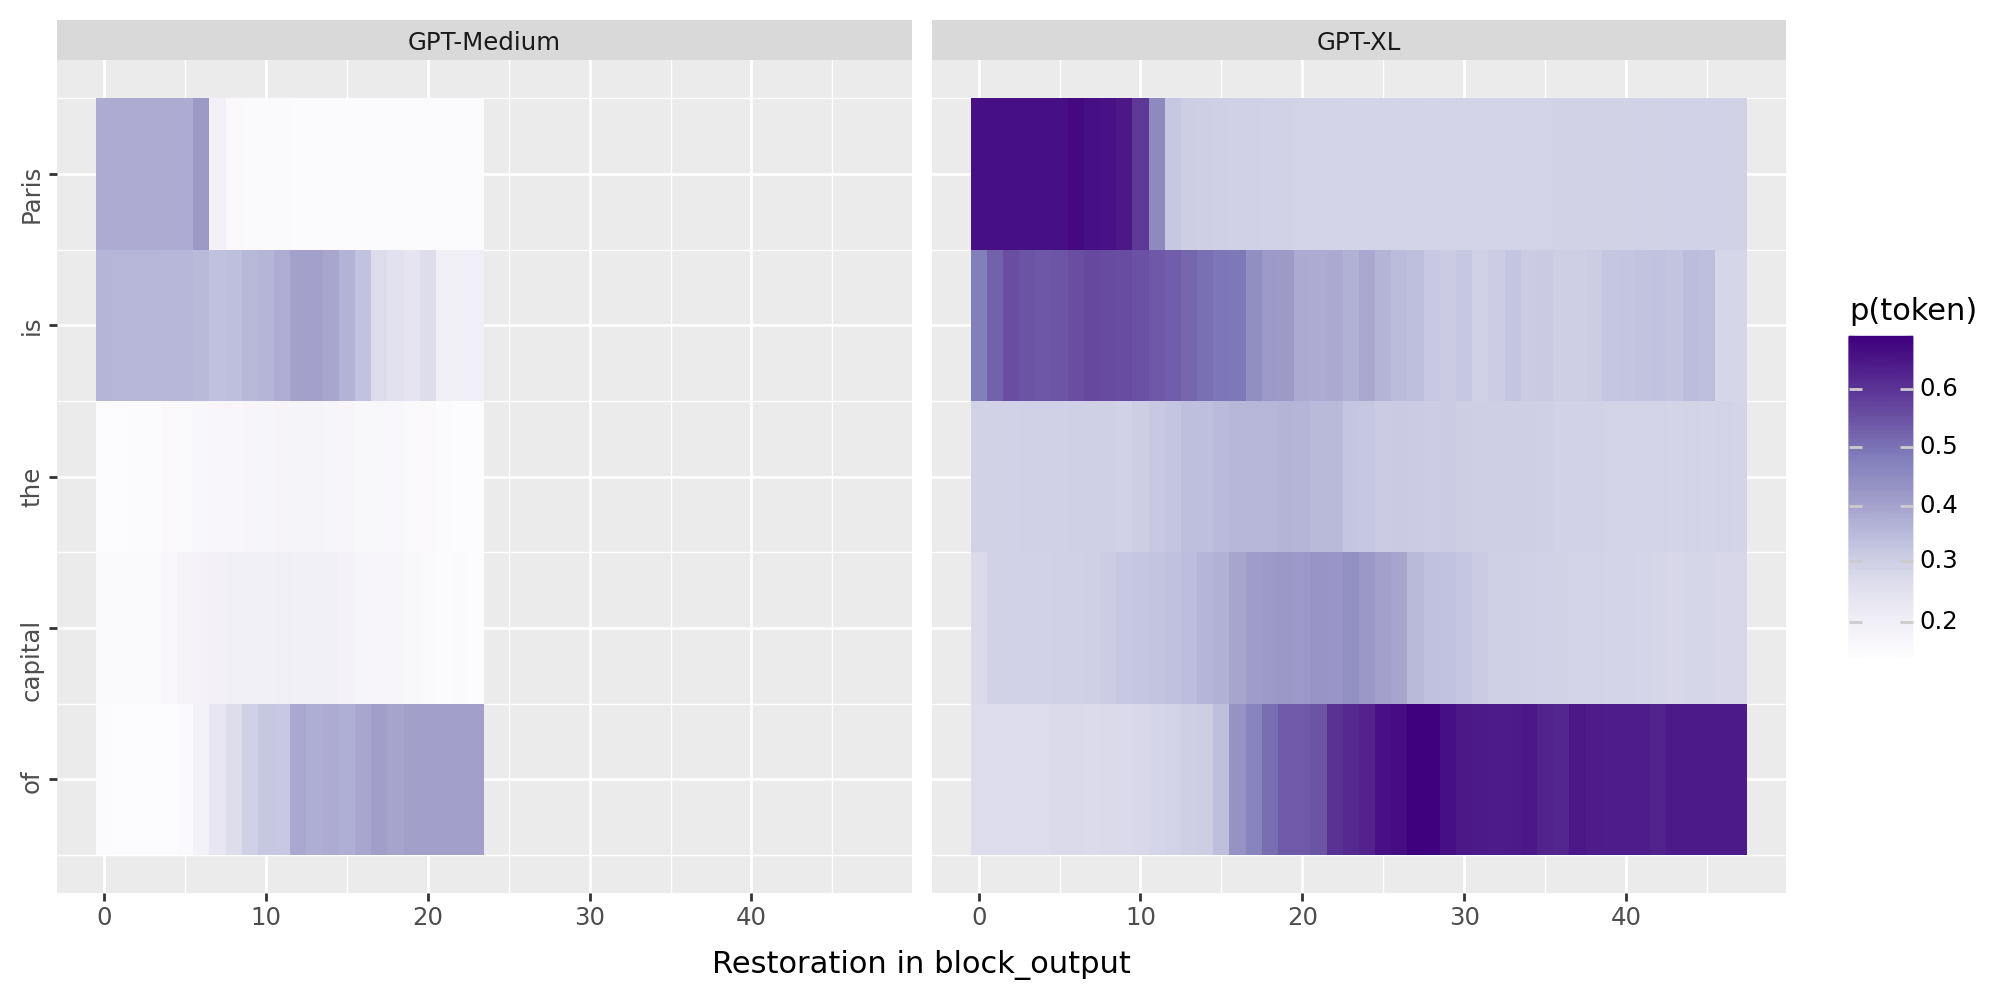

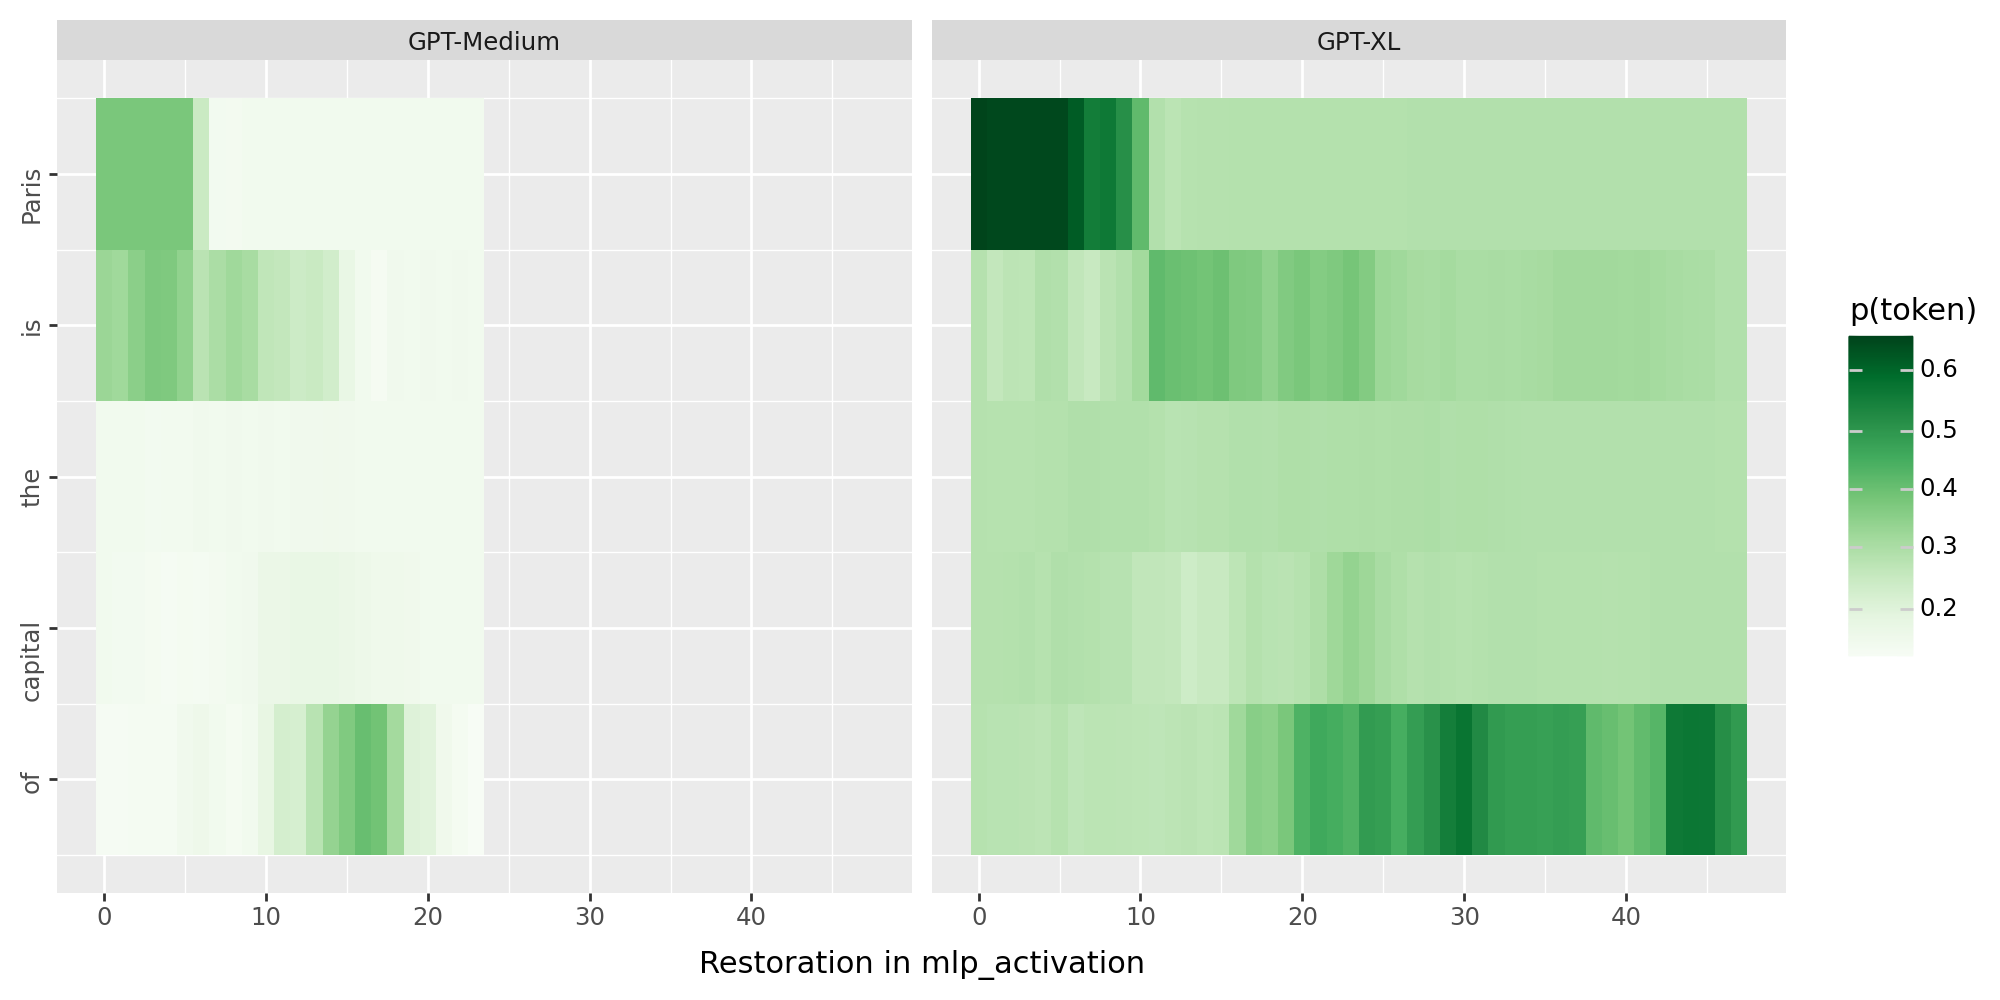

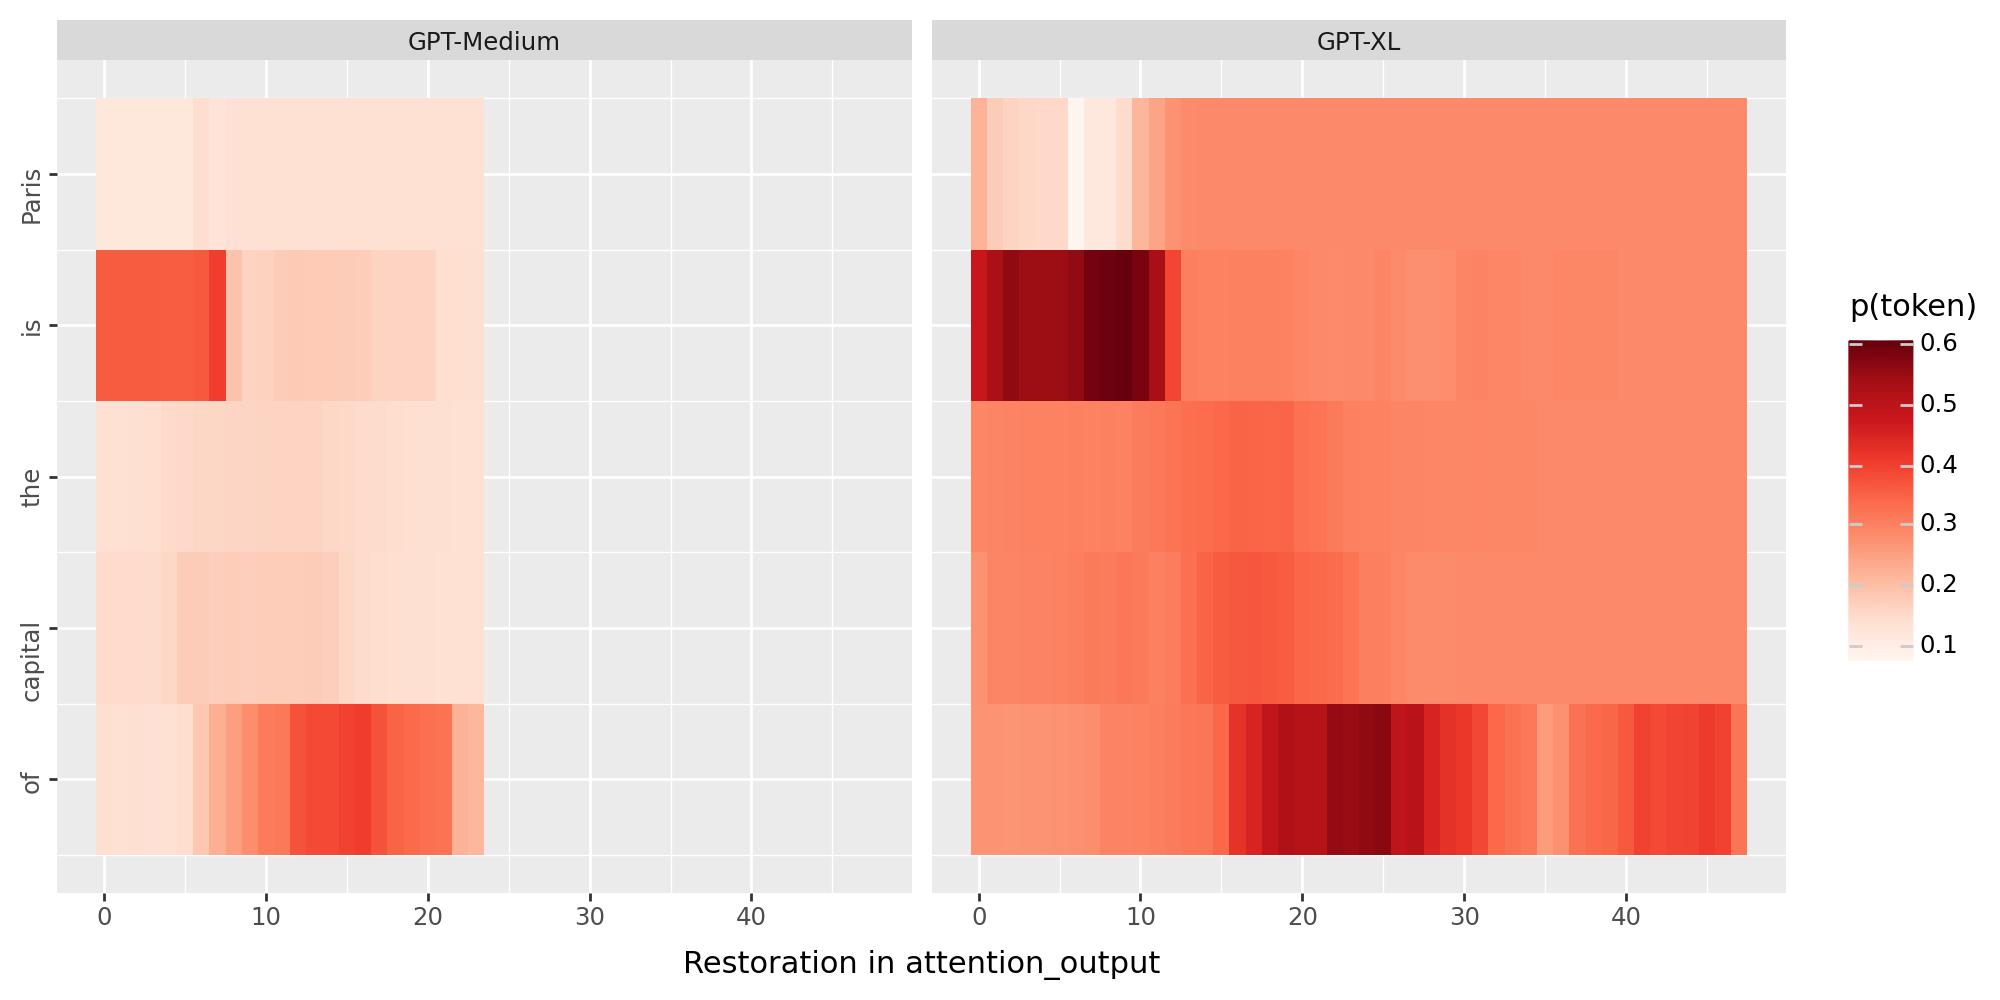

In [22]:
# Example Usage
plot_results_comparison(
    target=target,
    sentence=sentence
)


In [26]:
class NoiseIntervention(ConstantSourceIntervention, LocalistRepresentationIntervention):
    def __init__(self, embed_dim, **kwargs):
        super().__init__()
        self.interchange_dim = embed_dim
        rs = np.random.RandomState(1)
        prng = lambda *shape: rs.randn(*shape)
        self.noise = torch.from_numpy(
            prng(1, 2, embed_dim)).to(device)
        self.noise_level = 0.13462981581687927

    def forward(self, base, source=None, subspaces=None):
        base[..., : self.interchange_dim] += self.noise * self.noise_level
        return base

    def __str__(self):
        return f"NoiseIntervention(embed_dim={self.embed_dim})"

Albert Einstein was a theoretical :
GPT2-xl: 


Analyzing attention_output: 100%|██████████| 48/48 [01:25<00:00,  1.79s/it]


GPT2-medium: 


Analyzing attention_output: 100%|██████████| 24/24 [00:20<00:00,  1.16it/s]


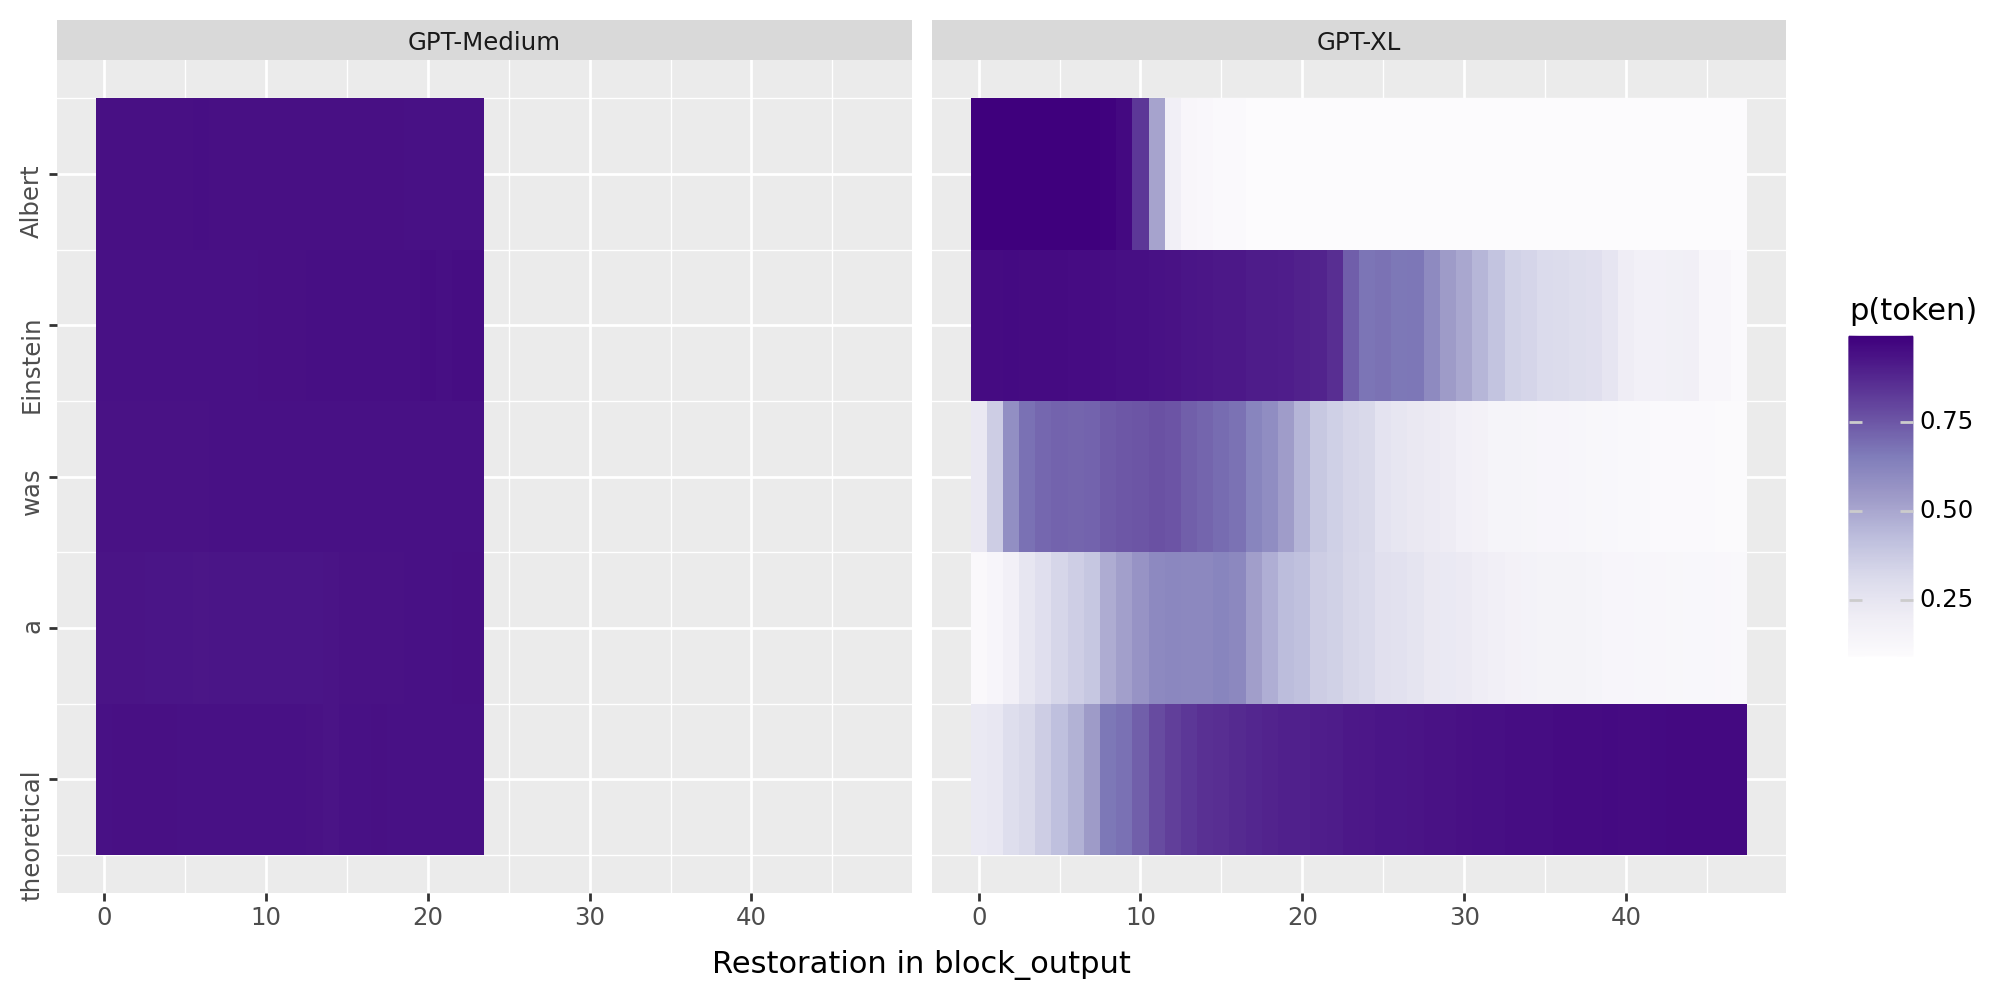

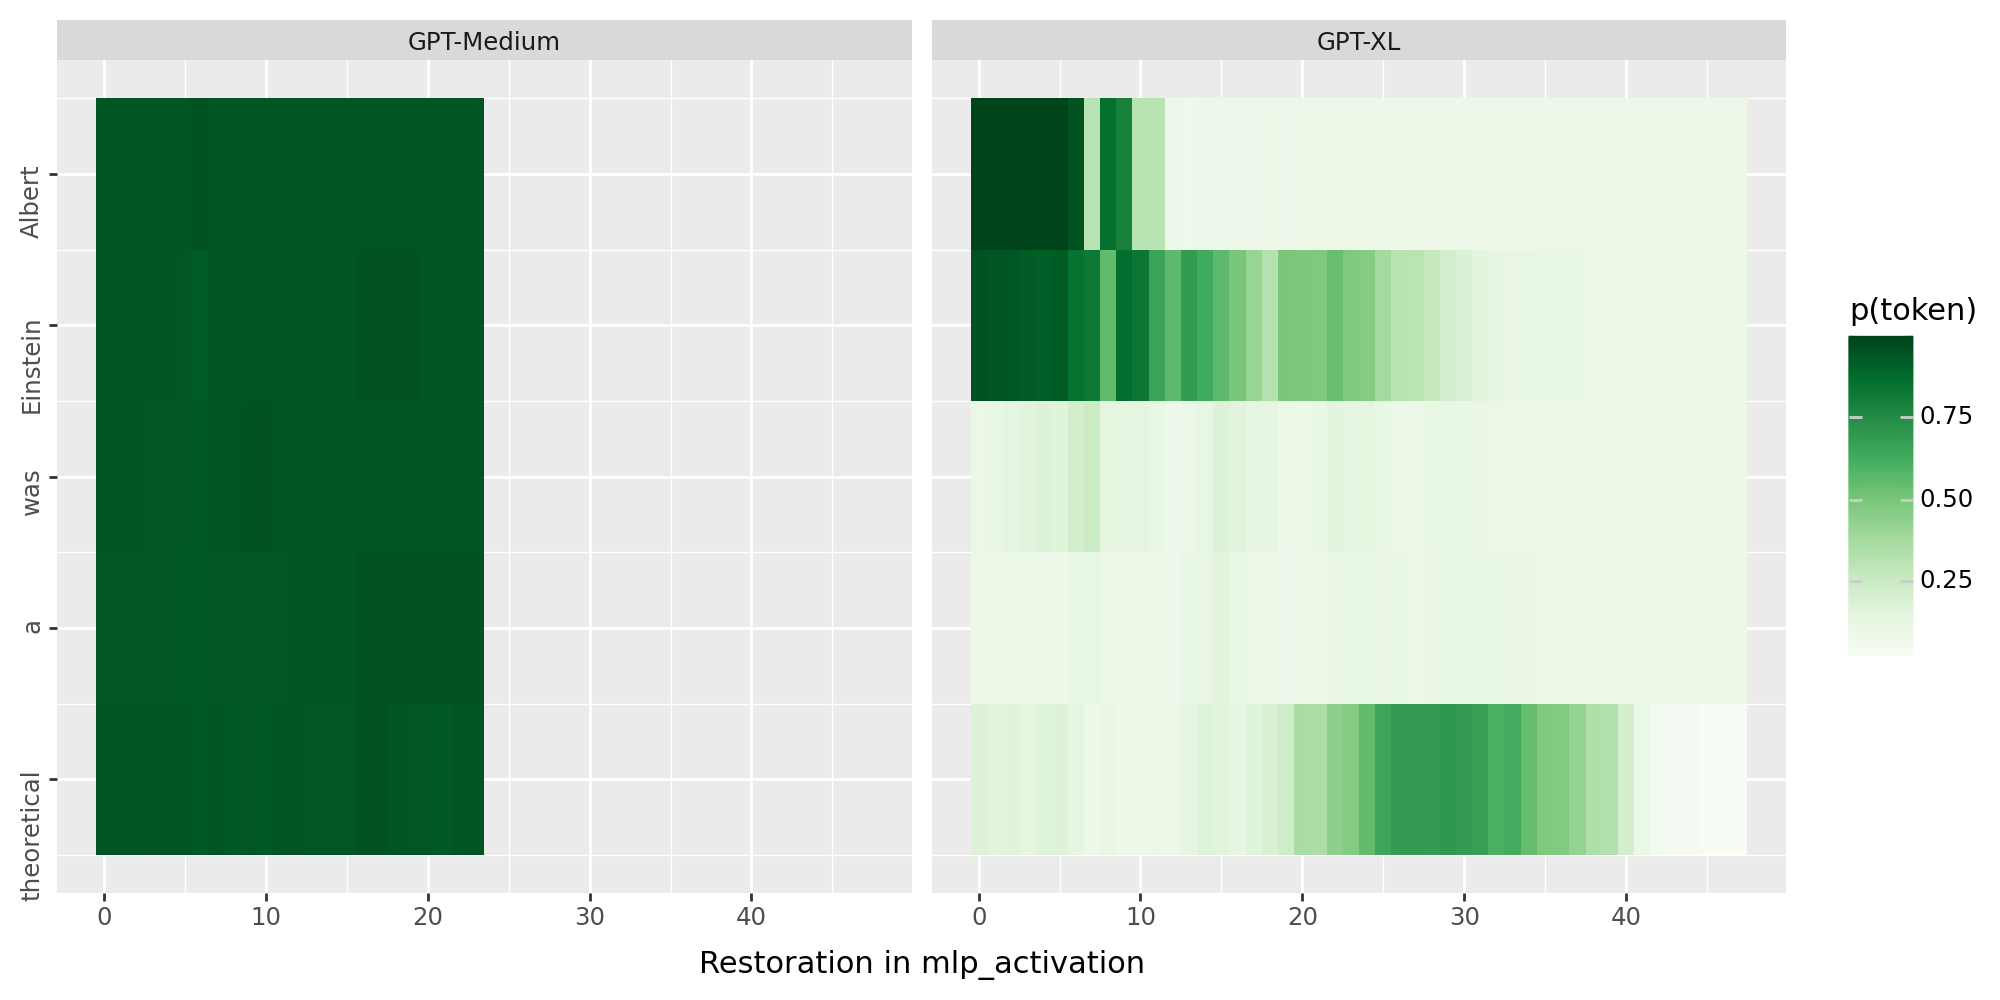

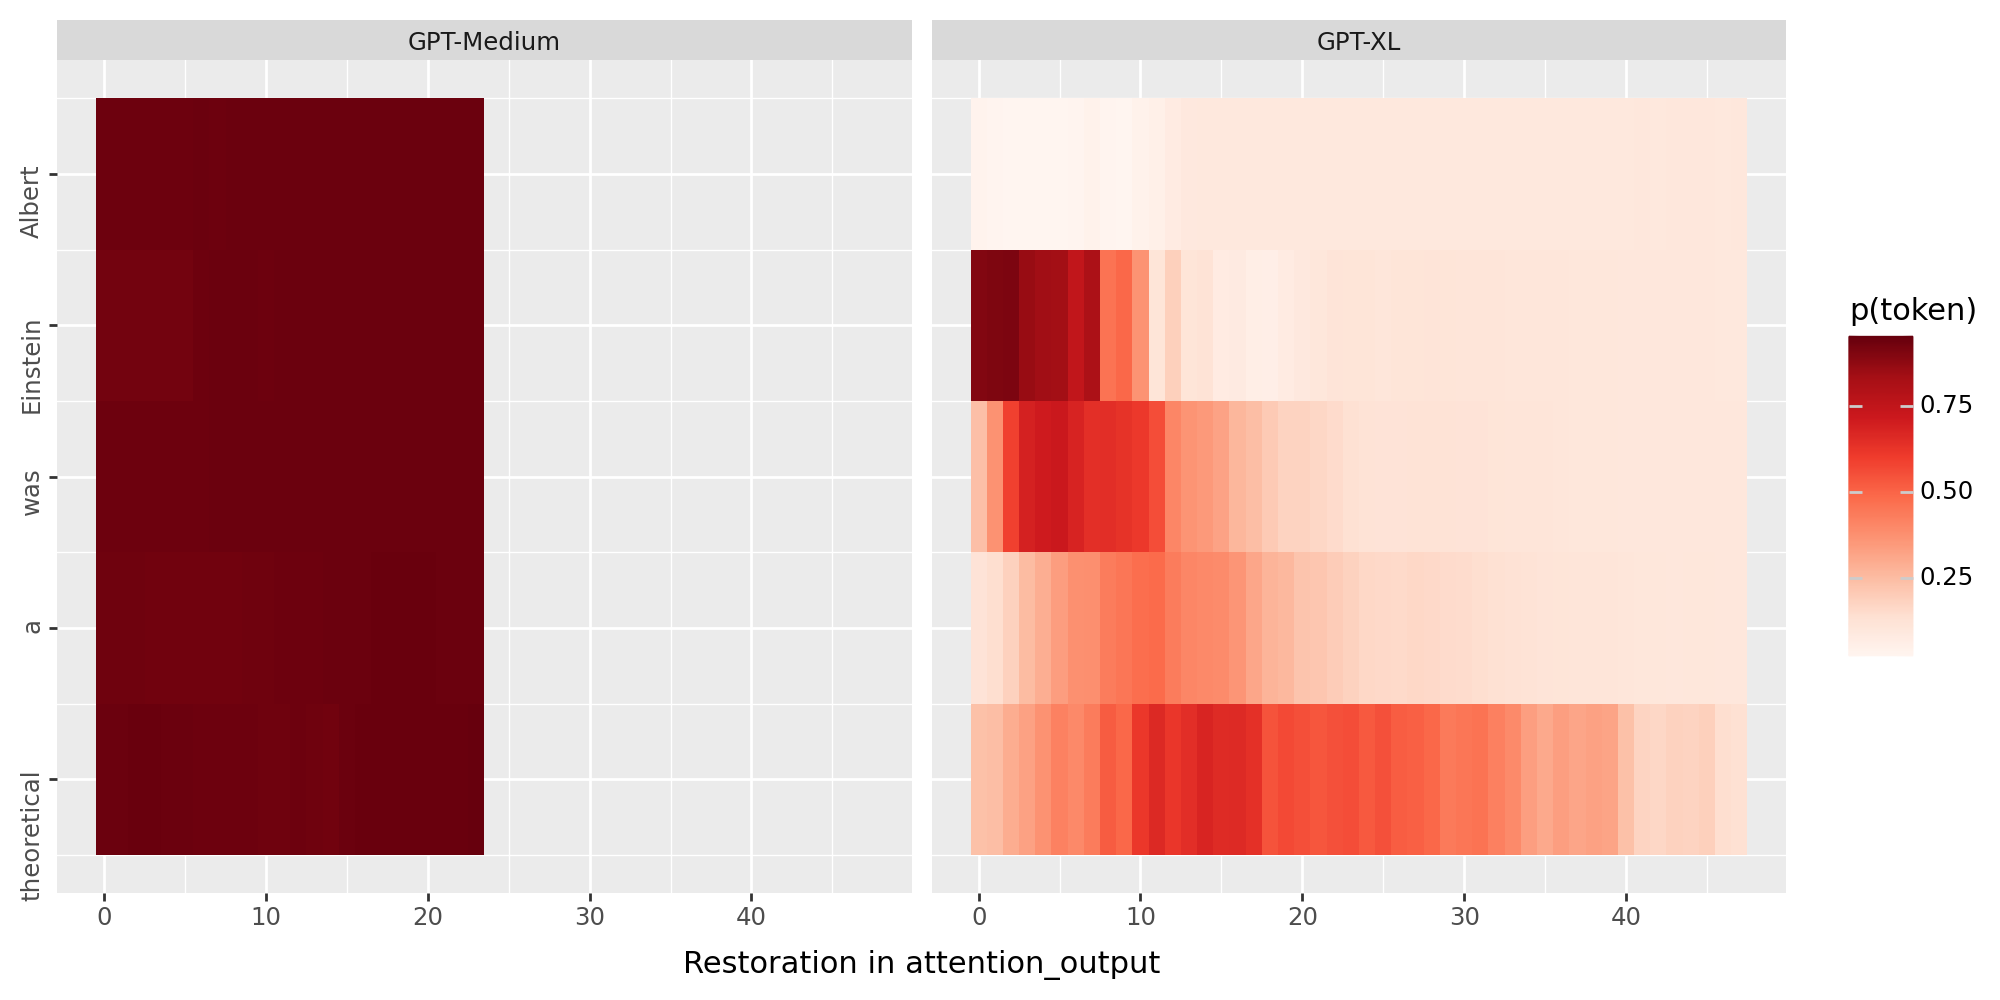

In [27]:
sentence = "Albert Einstein was a theoretical"
target = " physicist"
subject = [0, 1]
print(sentence, ":")
print("GPT2-xl: ")
analyze_sentence(gptxl, tokenizerxl, configxl, sentence, target, subject, f"./{target[1:]}/results_gptxl")
print("GPT2-medium: ")
analyze_sentence(gptmedium, tokenizermedium, configmedium, sentence, target, subject, f"./{target[1:]}/results_medium")
print("")

# Example Usage
plot_results_comparison(
    target=target,
    sentence=sentence
)

Neil Armstrong was the first person to walk on the :
GPT2-xl: 


Analyzing attention_output: 100%|██████████| 48/48 [03:19<00:00,  4.16s/it]


GPT2-medium: 


Analyzing attention_output: 100%|██████████| 24/24 [00:40<00:00,  1.69s/it]


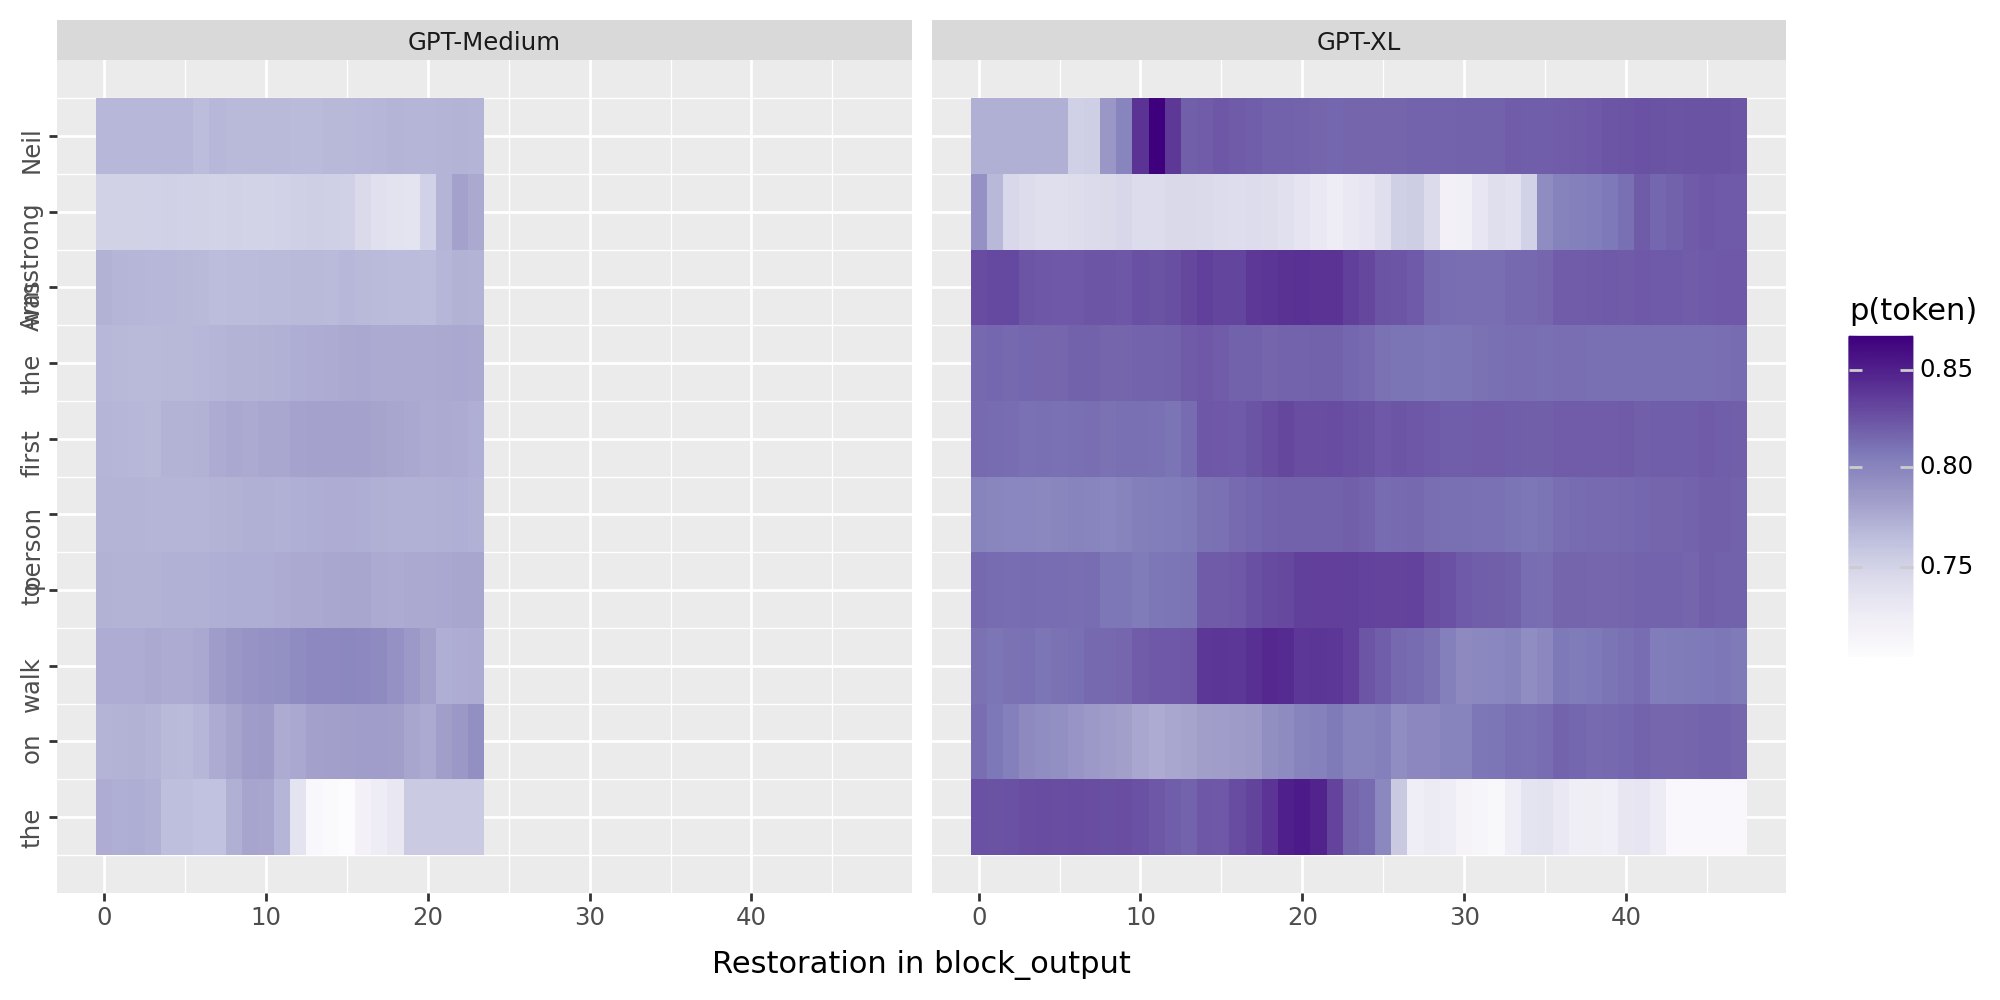

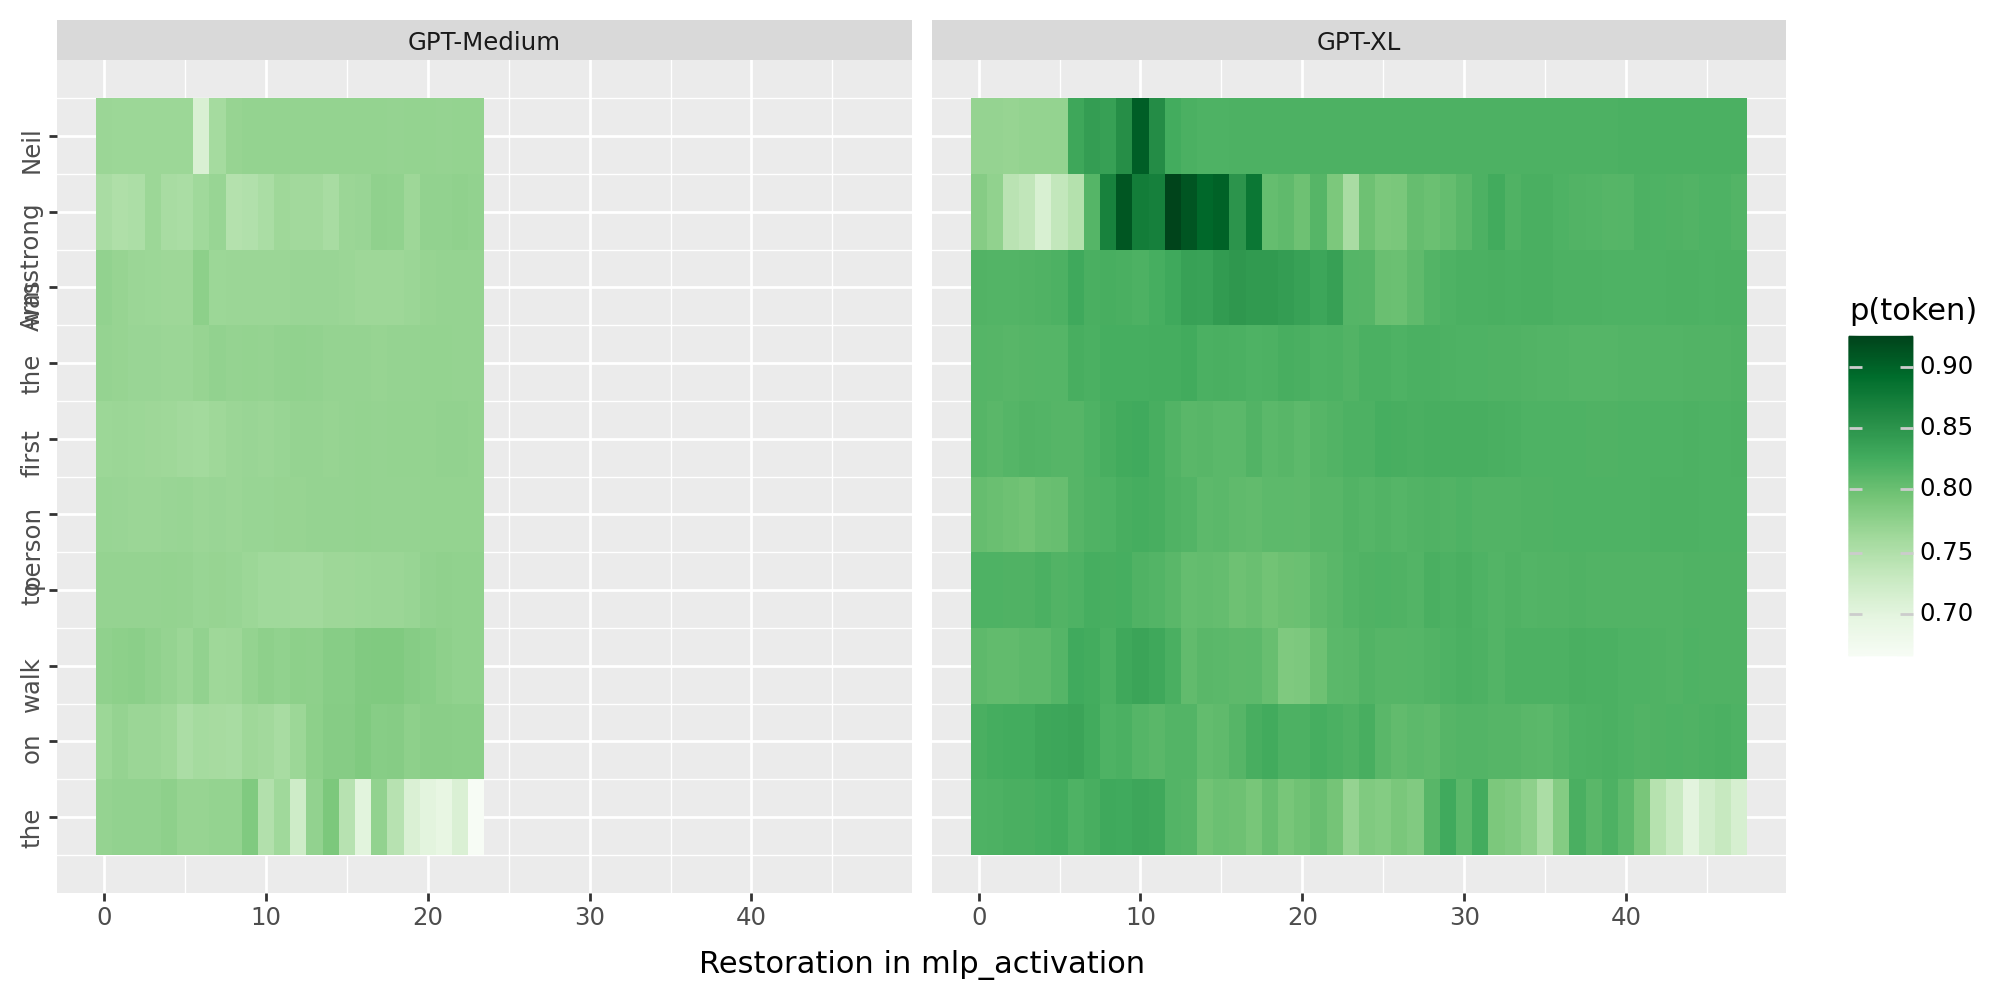

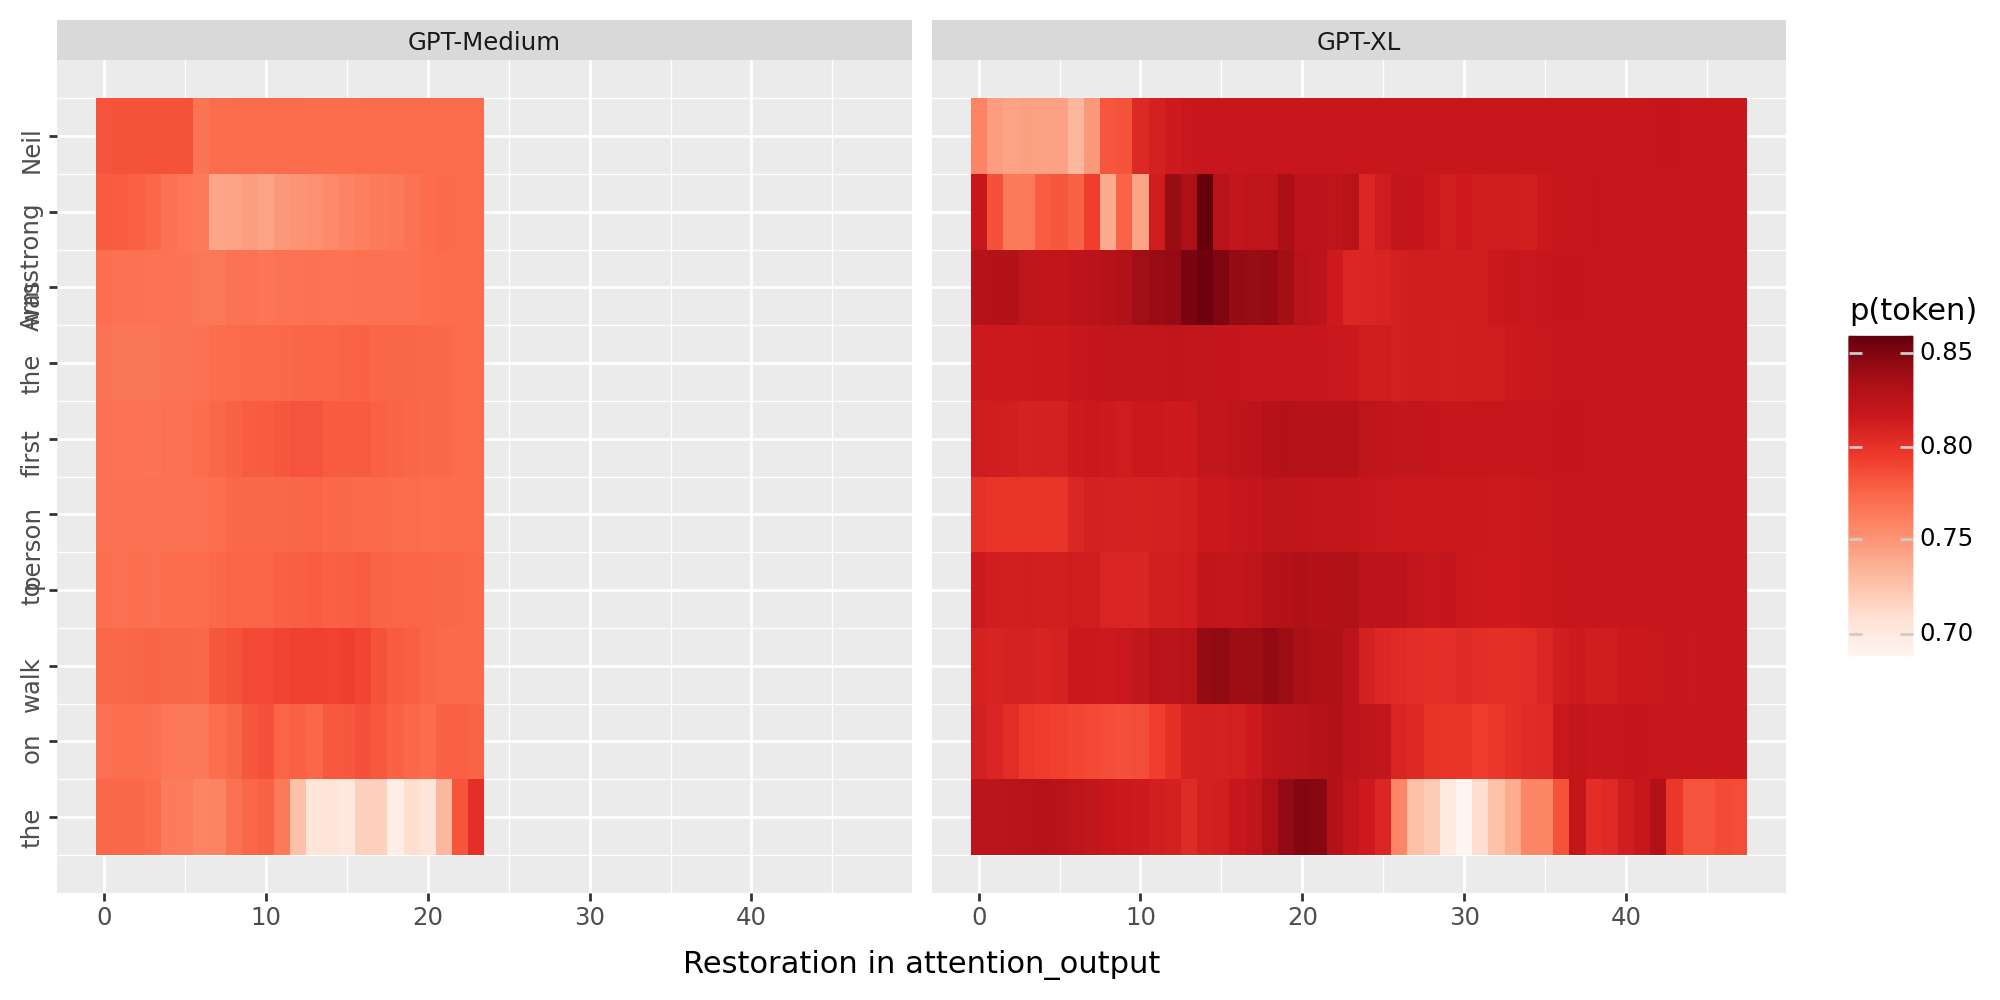

In [28]:
sentence = "Neil Armstrong was the first person to walk on the"
target = " moon"
subject = [0, 1]
print(sentence, ":")
print("GPT2-xl: ")
analyze_sentence(gptxl, tokenizerxl, configxl, sentence, target, subject, f"./{target[1:]}/results_gptxl")
print("GPT2-medium: ")
analyze_sentence(gptmedium, tokenizermedium, configmedium, sentence, target, subject, f"./{target[1:]}/results_medium")
print("")

# Example Usage
plot_results_comparison(
    target=target,
    sentence=sentence
)

In [ ]:
class NoiseIntervention(ConstantSourceIntervention, LocalistRepresentationIntervention):
    def __init__(self, embed_dim, **kwargs):
        super().__init__()
        self.interchange_dim = embed_dim
        rs = np.random.RandomState(1)
        prng = lambda *shape: rs.randn(*shape)
        self.noise = torch.from_numpy(
            prng(1, 3, embed_dim)).to(device)
        self.noise_level = 0.13462981581687927

    def forward(self, base, source=None, subspaces=None):
        base[..., : self.interchange_dim] += self.noise * self.noise_level
        return base

    def __str__(self):
        return f"NoiseIntervention(embed_dim={self.embed_dim})"

Marie Curie discovered :
GPT2-xl: 


Analyzing attention_output: 100%|██████████| 48/48 [01:06<00:00,  1.38s/it]


GPT2-medium: 


Analyzing attention_output: 100%|██████████| 24/24 [00:16<00:00,  1.50it/s]


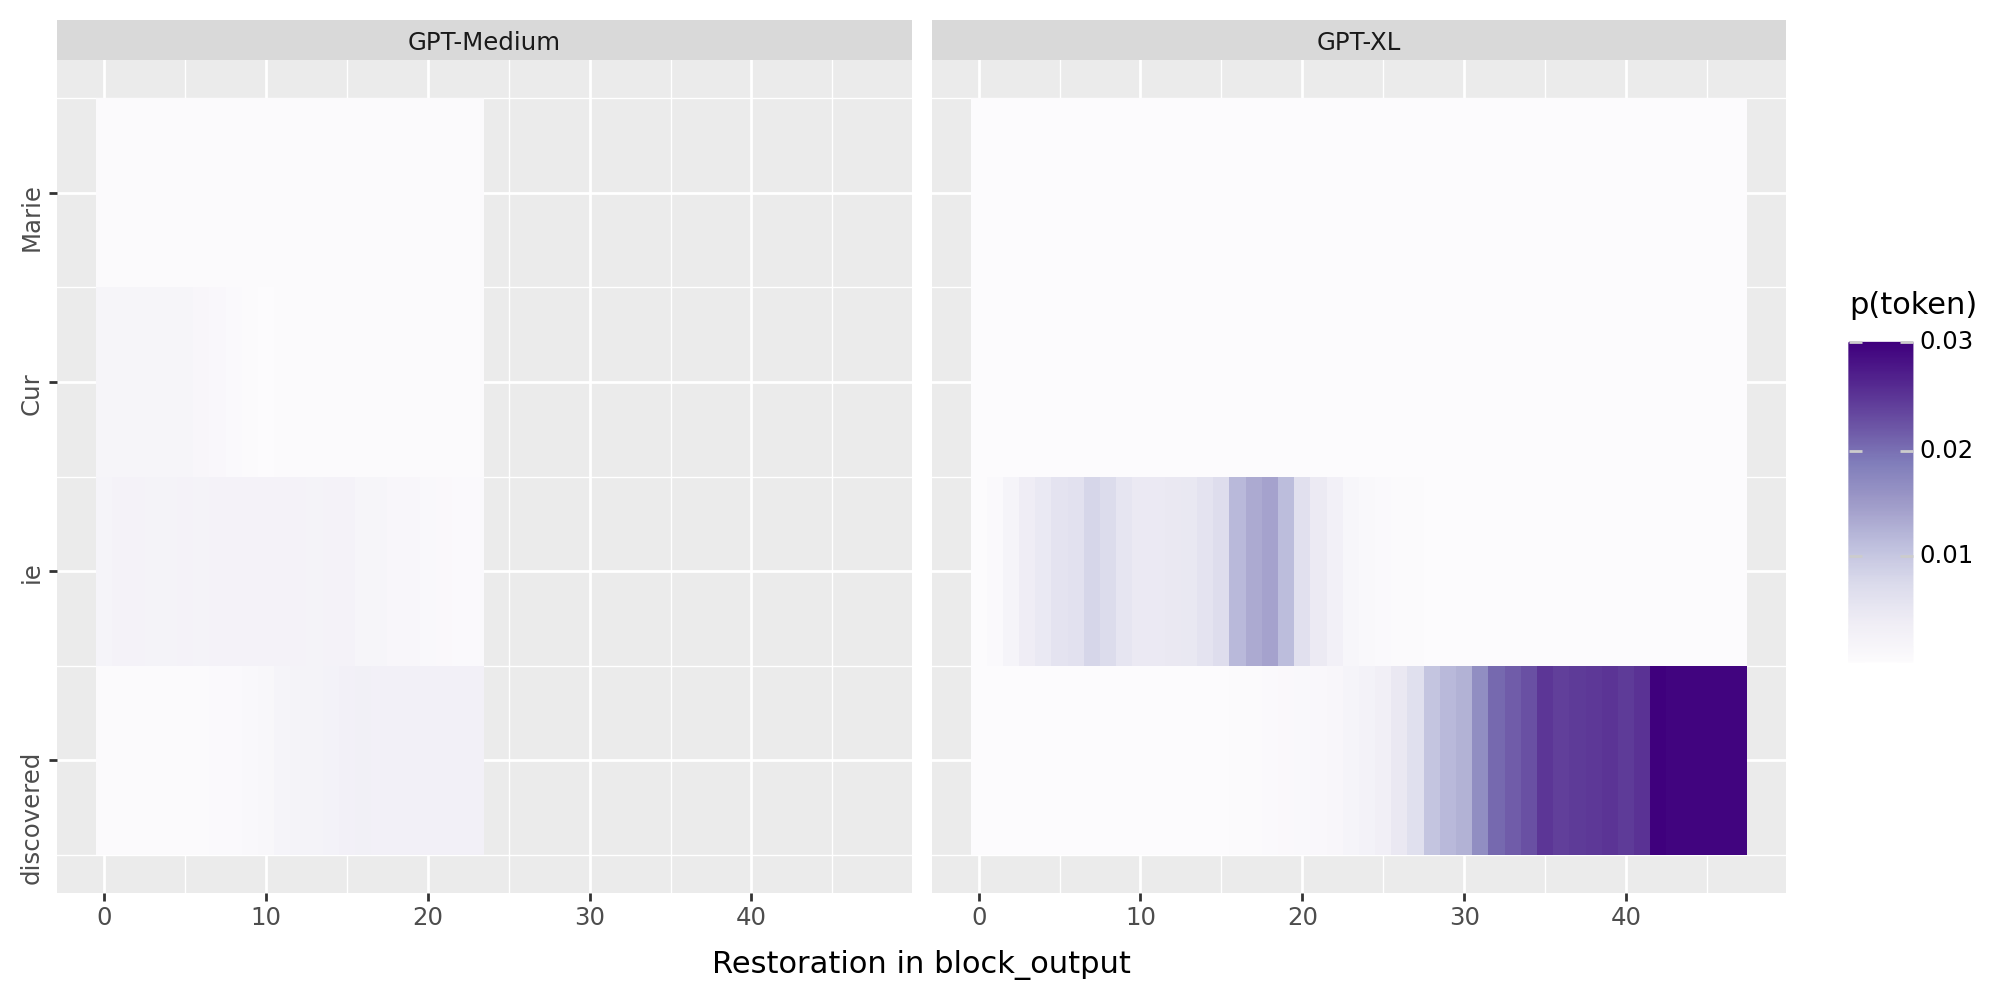

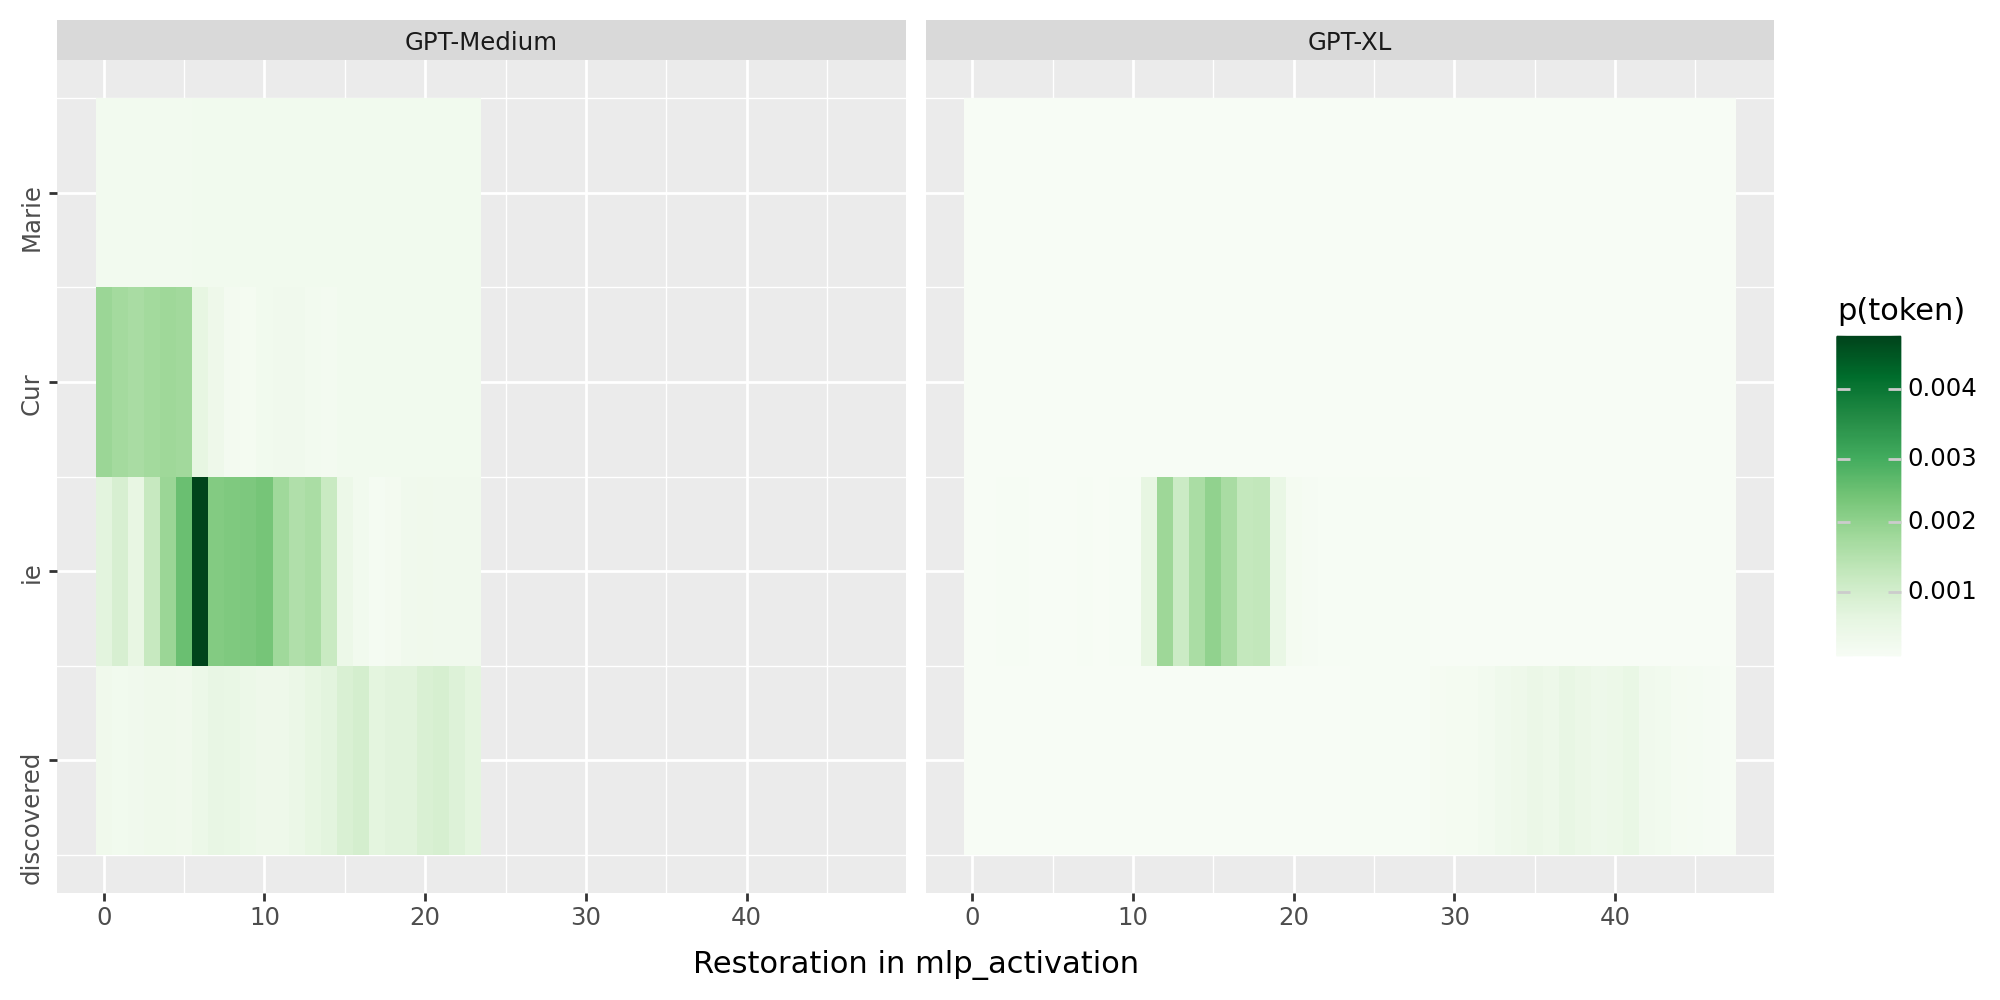

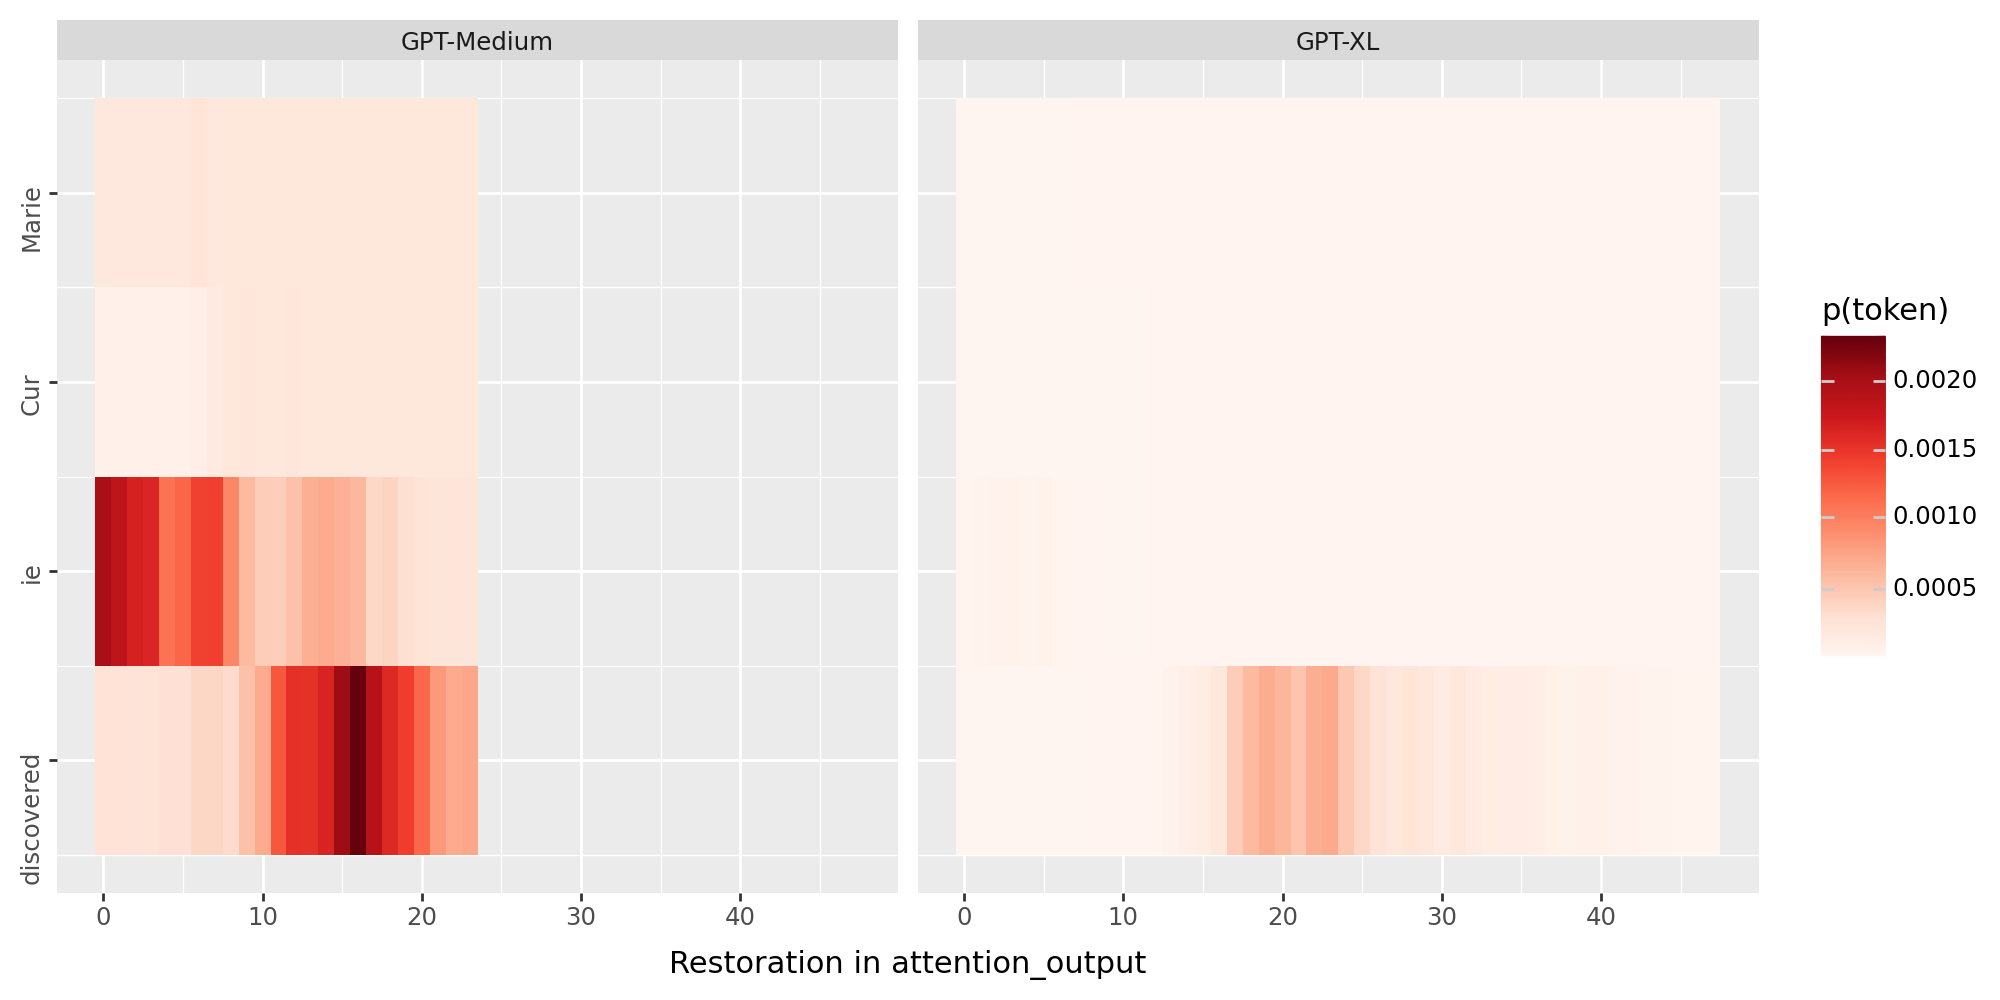

In [30]:
sentence = "Marie Curie discovered"
target = " radium"
subject = [0, 1, 2]
print(sentence, ":")
print("GPT2-xl: ")
analyze_sentence(gptxl, tokenizerxl, configxl, sentence, target, subject, f"./{target[1:]}/results_gptxl")
print("GPT2-medium: ")
analyze_sentence(gptmedium, tokenizermedium, configmedium, sentence, target, subject, f"./{target[1:]}/results_medium")
print("")

# Example Usage
plot_results_comparison(
    target=target,
    sentence=sentence
)

The Amazon River is the largest river by discharge of :
GPT2-xl: 


Analyzing attention_output: 100%|██████████| 48/48 [03:19<00:00,  4.15s/it]


GPT2-medium: 


Analyzing attention_output: 100%|██████████| 24/24 [00:40<00:00,  1.70s/it]


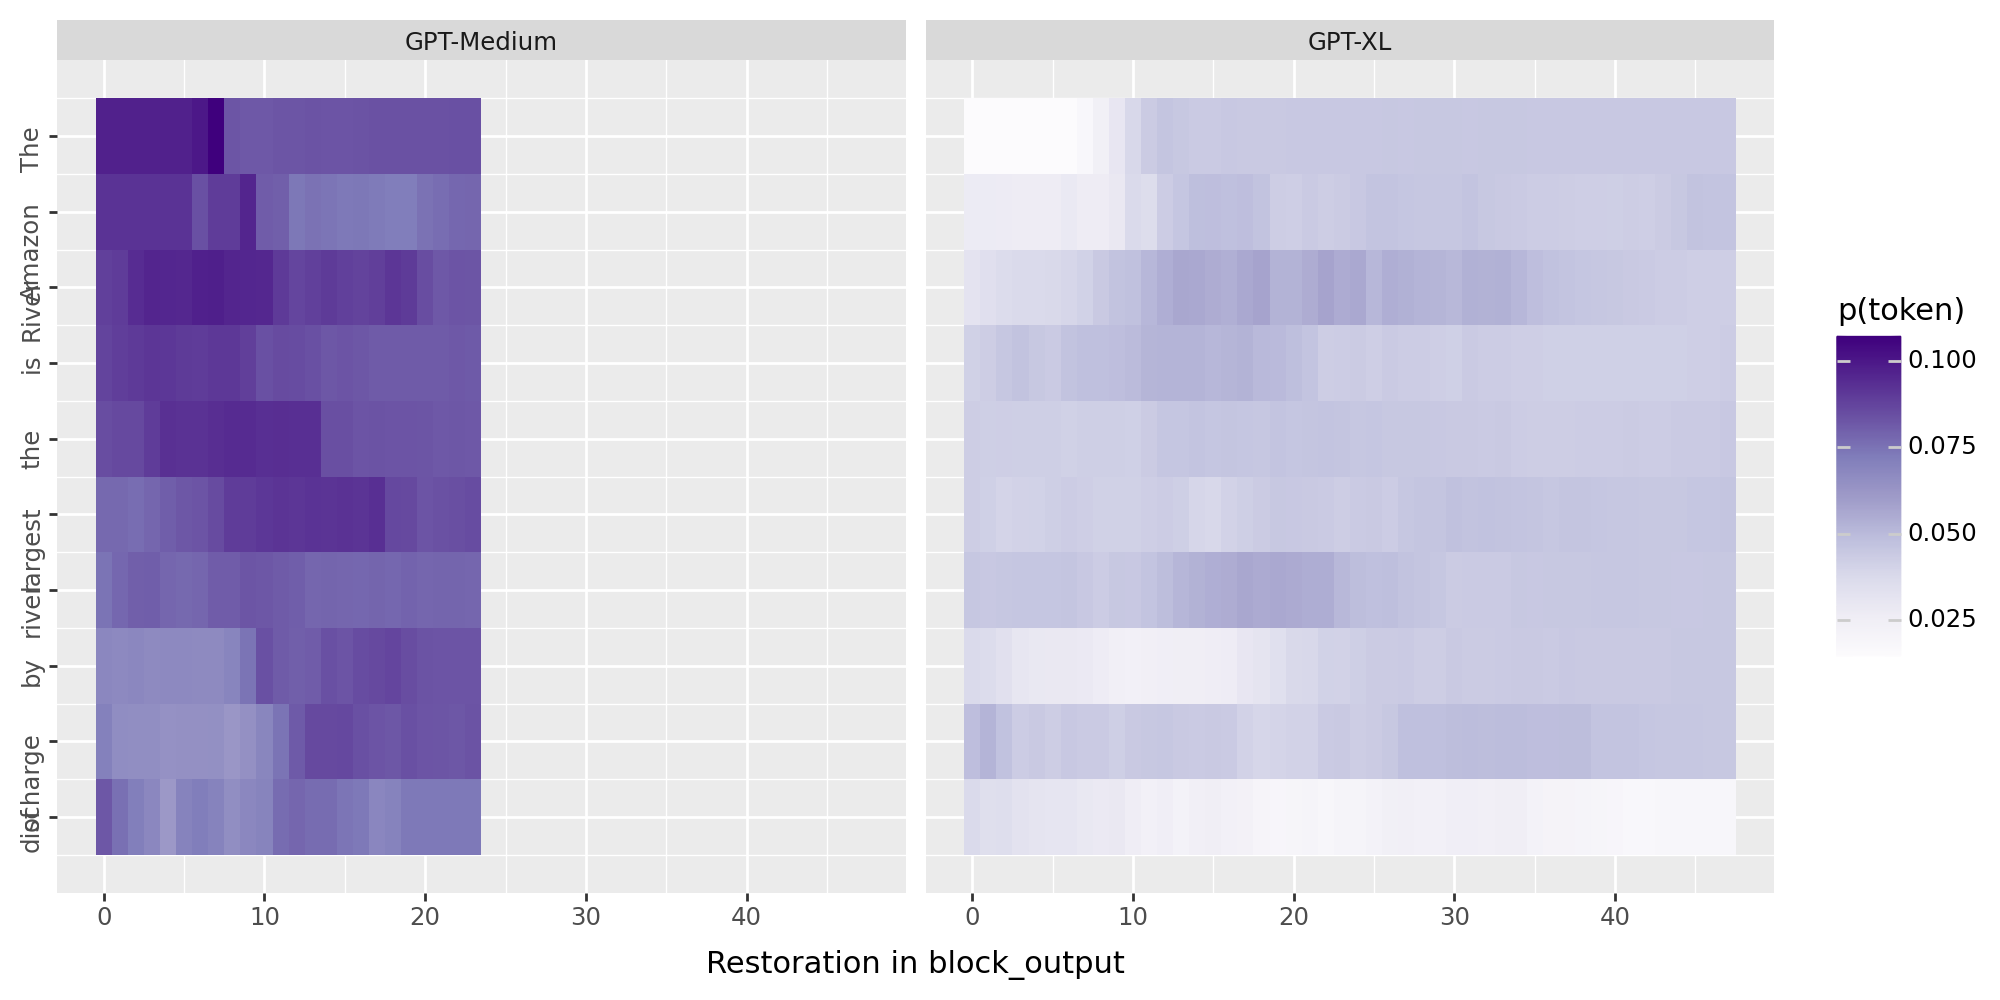

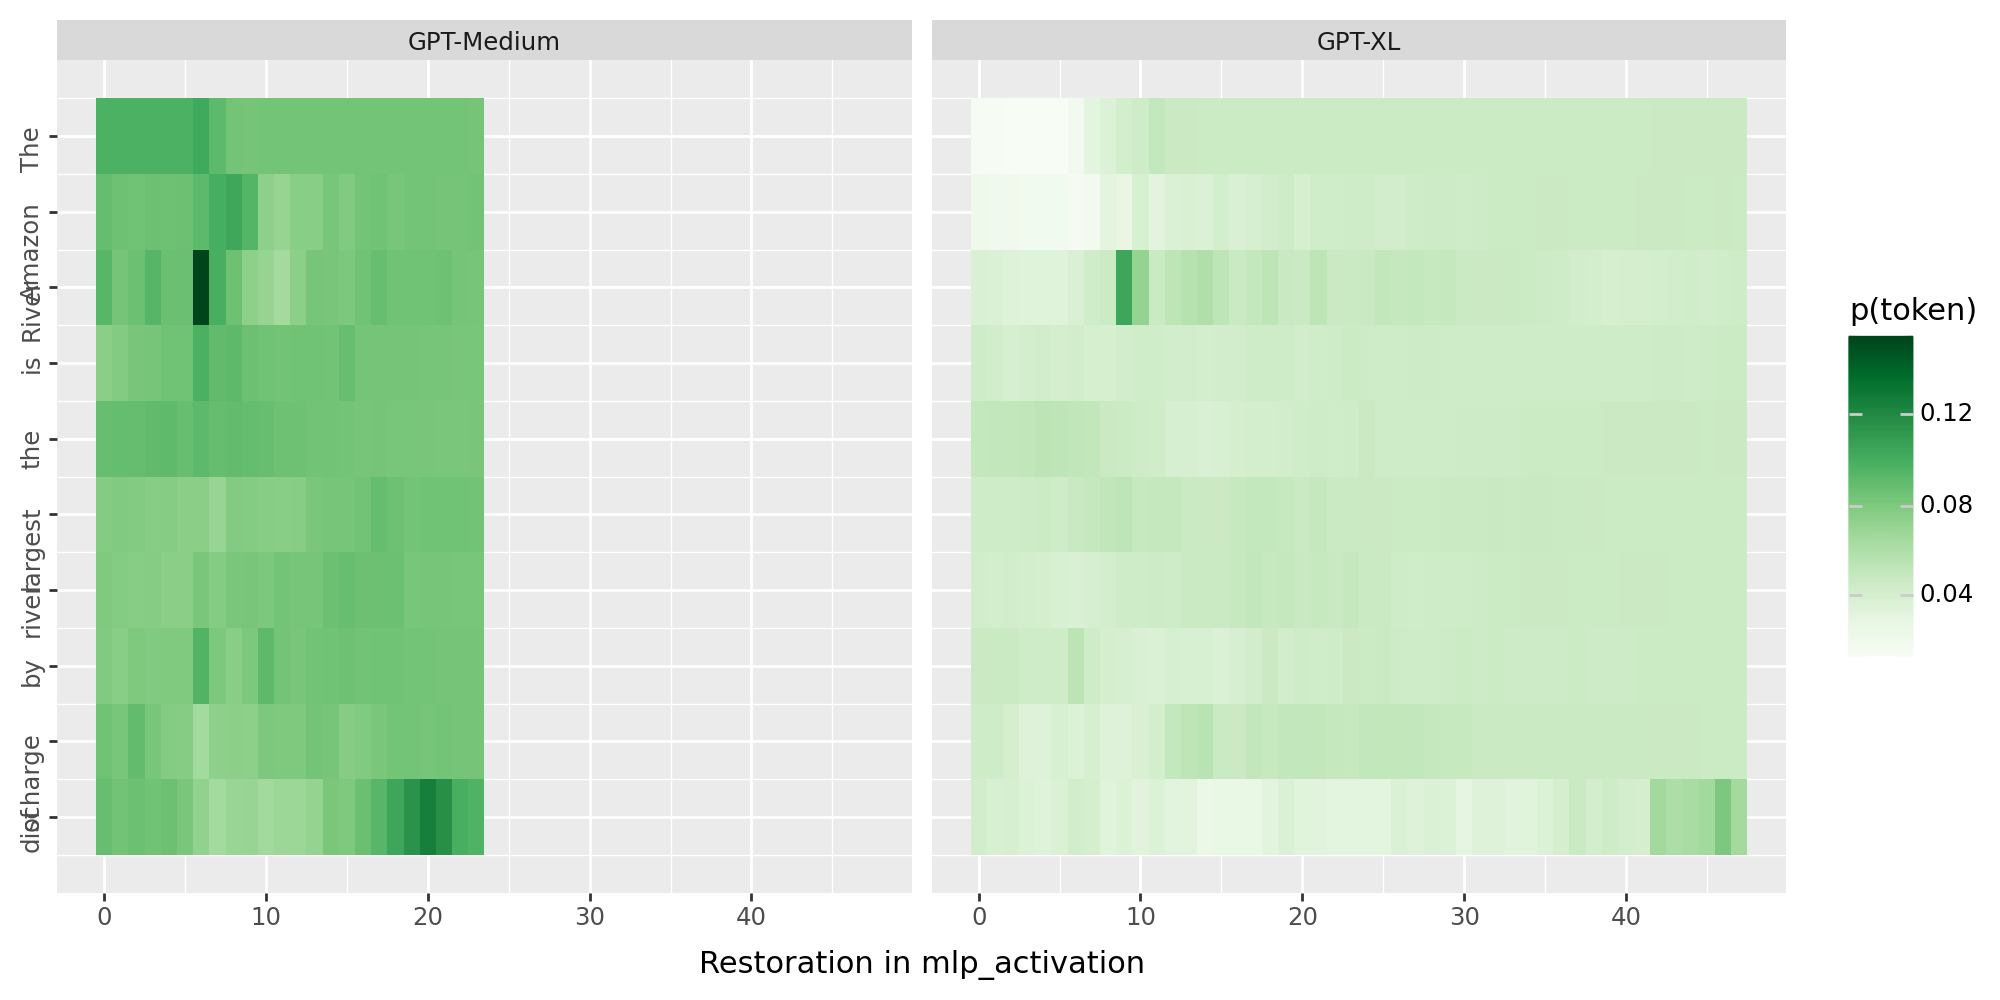

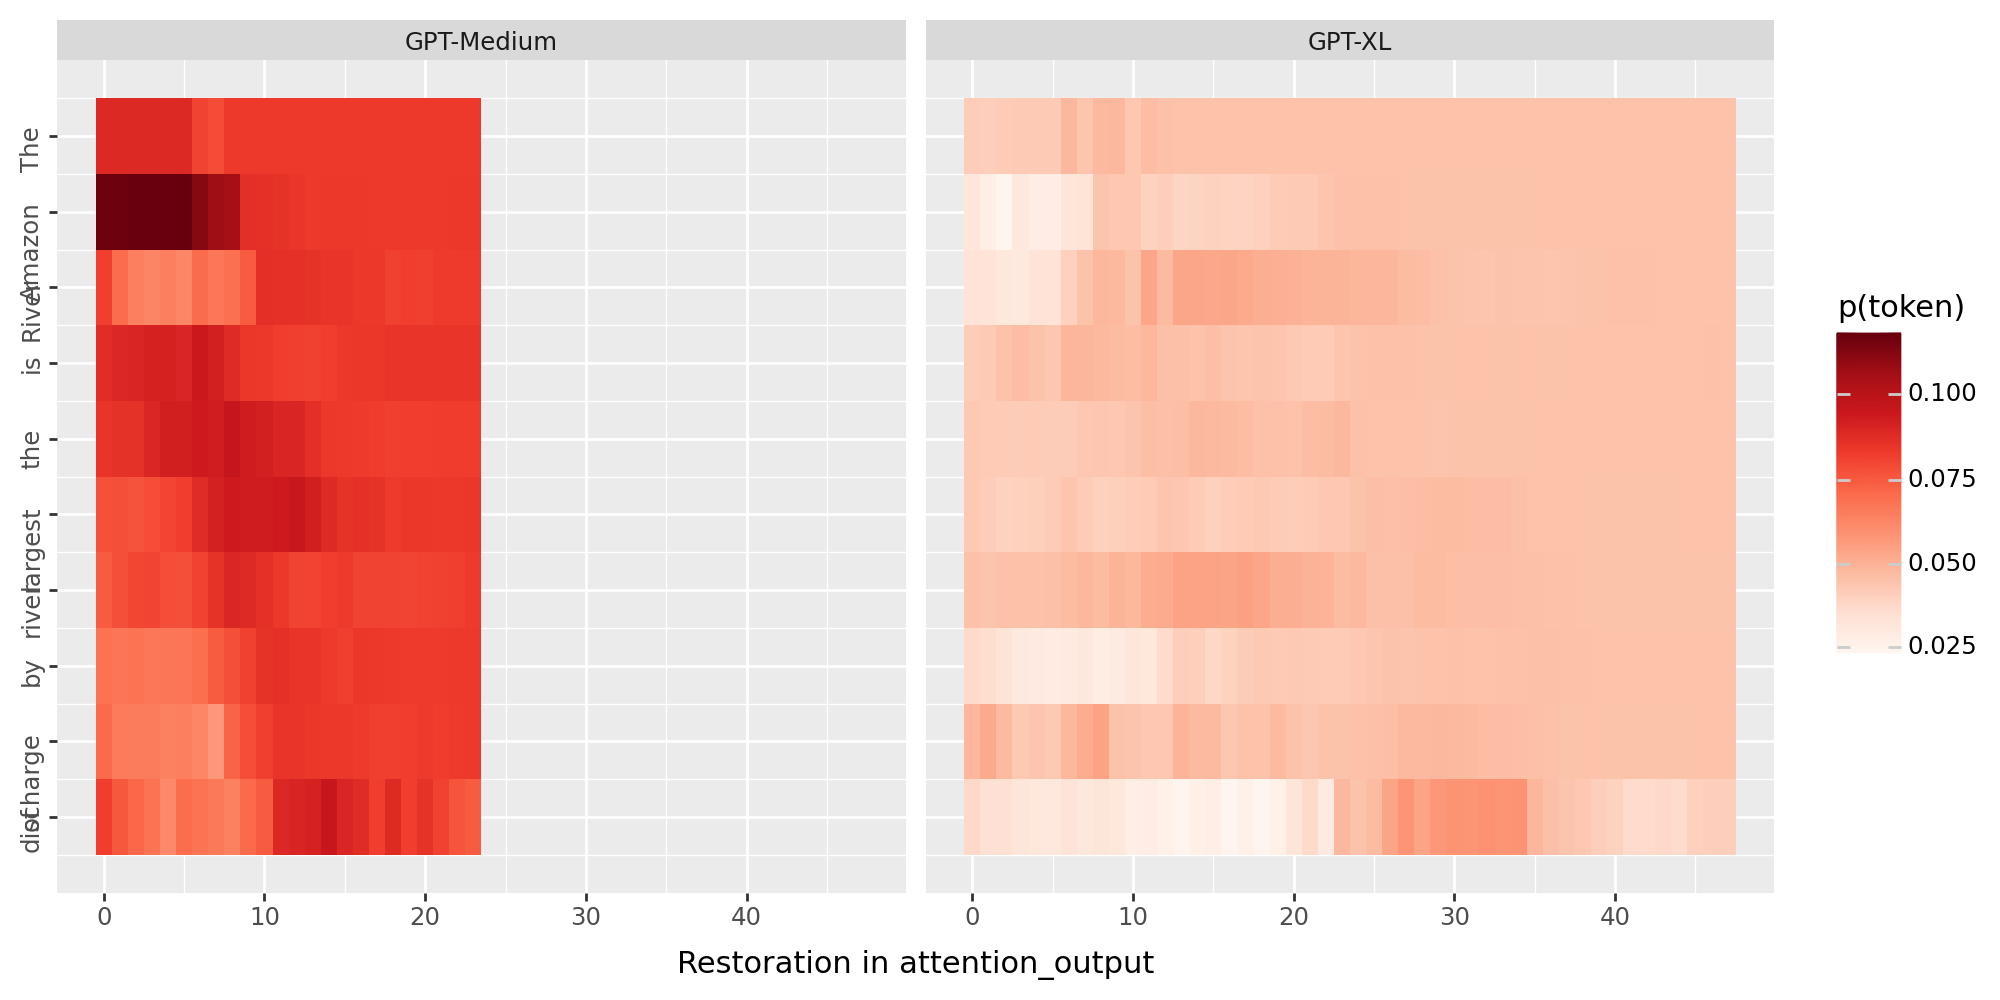

In [31]:
sentence = "The Amazon River is the largest river by discharge of"
target = " water"
subject = [0, 1, 2]
print(sentence, ":")
print("GPT2-xl: ")
analyze_sentence(gptxl, tokenizerxl, configxl, sentence, target, subject, f"./{target[1:]}/results_gptxl")
print("GPT2-medium: ")
analyze_sentence(gptmedium, tokenizermedium, configmedium, sentence, target, subject, f"./{target[1:]}/results_medium")
print("")

# Example Usage
plot_results_comparison(
    target=target,
    sentence=sentence
)